# Rush Hour: predicting hourly bike demand

This notebook runs the whole project from top to bottom. Every number comes from our own modules in `src/` and from the
JSON files in `artifacts/`; the cells only call them and show the results.

**Running it on Google Colab (or any fresh machine).** Upload this notebook and the two data files of the course,
`train.csv` and `test.csv`, then choose *Runtime → Run all*. Nothing else is needed: the setup cell below carries our
own project files (the modules in `src/`, `config.yaml`, the stored `artifacts/` and the empty submission template)
as text and unpacks them next to the notebook. It downloads nothing and never overwrites a file that already exists.
If the two data files have not been uploaded yet, the setup cell asks for them. On our own machines, where the project
folder is already there, the setup cell unpacks nothing.

**Runtime.** About two minutes. Phases 1 to 3 are computed live every time the notebook runs (seconds each) and
compared with the artifacts of our own run. Phase 4 takes about 30 minutes to compute and Phase 5 about 3, so those
two cells load the stored artifact when the configuration and the upstream artifact are unchanged, and say so.
To recompute the whole chain from scratch set `RECOMPUTE_ALL = True` in the configuration cell (about 40 minutes).
Numbers recomputed on another machine can differ from the text in the last digits, because the markdown cells quote
the stored run.

**Where the code is.** The cells call our modules in `src/`; the core algorithms are printed where they are used
(`show_source`), and once the setup cell has run every file can be opened from the file browser.

**How to change a setting.** Every knob lives in `config.yaml`. To try a different value, edit the `CFG` dictionary in
the configuration cell (for example `CFG["p1"]["lr_fraction_of_bound"] = 0.9`) and re-run the later cells; the phase
cells pass `CFG` to the phase code. A phase whose configuration changed is recomputed, and so is everything after it,
so a change in Phase 1 or 2 costs the 30 minutes of Phase 4 and overwrites the stored artifacts and the submission
file (`git checkout -- artifacts sample_submission.csv` restores them in our repository; on Colab, restart and run the
setup cell again in a clean session). For a quick demonstration that does not touch the chain, call the functions
directly in a scratch cell (examples are in `docs/WALKTHROUGH.md`).

In [1]:
#@title Setup: unpack the project files (run this cell first)
# The long block of letters below is a compressed copy of src/, config.yaml and artifacts/, nothing else.
import base64
import hashlib
import io
import os
import shutil
import zipfile

BUNDLE = """
...
"""
DATA_SHA256 = {"train": "d75c65afa675373d63ef0f6e81324910605fd378031c2590e4a40c985005e2c1", "test": "2ba21ce32552fa770d0a560ca1512e6700aaaf3adc559a343b8884c80845ddea"}   # the data files our stored results were computed from

with zipfile.ZipFile(io.BytesIO(base64.b64decode(BUNDLE))) as bundle:
    members = bundle.namelist()
    missing_members = [m for m in members if not os.path.exists(m)]
    for member in missing_members:
        bundle.extract(member, ".")
print(f"project files: {len(members)} in the bundle, {len(missing_members)} unpacked now, "
      f"{len(members) - len(missing_members)} already present")
del BUNDLE

import yaml

DATA_PATHS = {key: yaml.safe_load(open("config.yaml", encoding="utf-8"))["paths"][key] for key in DATA_SHA256}


def find_data_file(target):
    """An uploaded copy of a data file: next to the notebook, or in Colab's upload folder."""
    for folder in (".", "/content"):
        candidate = os.path.join(folder, os.path.basename(target))
        if os.path.isfile(candidate):
            return candidate
    return None


def place_data_files():
    """Copy uploaded data files to the paths config.yaml expects; return the ones still missing."""
    still_missing = []
    for target in DATA_PATHS.values():
        if not os.path.isfile(target):
            found = find_data_file(target)
            if found is None:
                still_missing.append(target)
            else:
                os.makedirs(os.path.dirname(target) or ".", exist_ok=True)
                shutil.copy(found, target)
    return still_missing


needed = place_data_files()
if needed:
    names = [os.path.basename(target) for target in needed]
    try:
        from google.colab import files as colab_files
    except ImportError:
        raise FileNotFoundError(f"put {names} next to this notebook (or in data/) and run this cell again") from None
    print("please choose these files in the upload box:", names)
    for name, content in colab_files.upload().items():
        for target in needed:   # Colab may rename a second upload to 'train (1).csv', so match on the stem
            if name.startswith(os.path.splitext(os.path.basename(target))[0]):
                os.makedirs(os.path.dirname(target) or ".", exist_ok=True)
                with open(target, "wb") as handle:
                    handle.write(content)
    needed = place_data_files()
    if needed:
        raise FileNotFoundError(f"still missing: {needed}; upload them and run this cell again")

DATA_MATCHES = True
for key, target in DATA_PATHS.items():
    with open(target, "rb") as handle:
        digest = hashlib.sha256(handle.read().replace(b"\r\n", b"\n")).hexdigest()
    same = digest == DATA_SHA256[key]
    DATA_MATCHES = DATA_MATCHES and same
    print(f"{target}: {'the file our stored results were computed from' if same else 'DIFFERENT from the file our stored results were computed from'}")
if not DATA_MATCHES:
    print("The stored artifacts do not belong to these data files: set RECOMPUTE_ALL = True in the configuration cell.")

project files: 35 in the bundle, 0 unpacked now, 35 already present
data/train.csv: the file our stored results were computed from
data/test.csv: the file our stored results were computed from


In [2]:
# The configuration and the imports for the whole notebook: every knob lives in CFG, which is loaded from config.yaml.
import sys

sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
from IPython.display import display

from src import nbview as view, plots
from src.common import config_seed, load_config, load_train, seeded_split, team_seed
from src.nbtools import phase, show_source
from src.plots import show  # displays a figure as a PNG in the notebook

CFG = load_config()
RECOMPUTE_ALL = False   # True: recompute every phase from scratch (about 40 minutes) instead of loading artifacts
SEED = config_seed(CFG)
assert team_seed(["34521", "40218", "41190"]) == 41698   # the worked example of the brief
view.p0_config(CFG, SEED)

item,value
team ids,"16007032, 16009837, 16006283"
seed,"44615 (sha256 of the sorted ids joined by '_', mod 100000)"
self-test,41698 reproduced from the brief's example ids
"Phase 1 learning rate, as a fraction of the stability bound",0.5000
Phase 2 degree candidates,"1, 2, 3, 4"
plateau tolerance,0.00100


In [3]:
# The labelled data and the one seeded 80/20 split that every reported score uses.
train_all = load_train(CFG)
train_df, val_df = seeded_split(train_all, SEED, CFG["split"]["test_size"])
view.p0_split(train_all, train_df, val_df)

item,value
labelled rows,"10886, 17"
training rows,"8708, 17"
validation rows,"2178, 17"
columns,"instant, dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, cnt, ws_lag1, wet3"


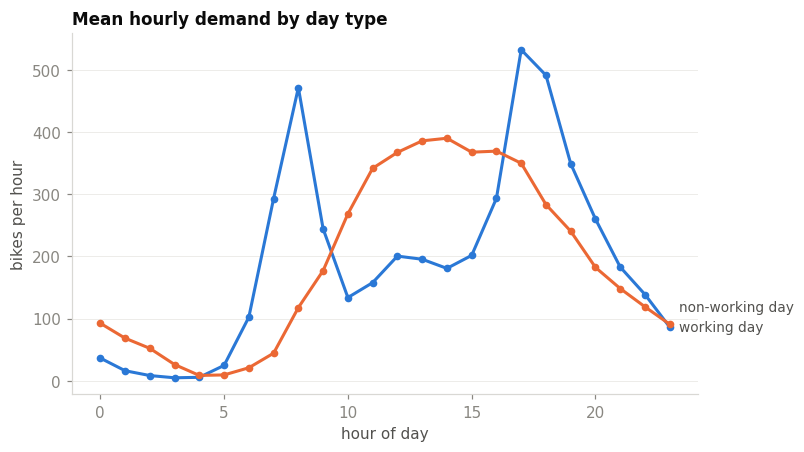

In [4]:
# Mean demand by hour for working and non-working days: the shape every model has to learn.
show(plots.plot_demand_profile(train_df))

In [5]:
# Oddities of the data that we checked before modelling.
view.p0_quirks(train_all)

item,value
rows with hum == 0,22
share of rows with windspeed == 0,0.1206
rows with weathersit == 1,7192
rows with weathersit == 2,2834
rows with weathersit == 3,859
rows with weathersit == 4,1
correlation of temp and atemp,0.9849
rows where workingday != (Mon-Fri and not holiday),0
rows where season != calendar quarter of mnth,0


### What we saw in the data before modelling

**About our expectations.** We looked at the data first, and that look included pilot fits, not only tables. Before writing any Expectation cell we had fitted quick closed-form least-squares models (scripts in `exp/eda0/`) to compare raw and log targets, hour encodings, the working-day × hour block, a first version of the complexity ladder and three candidate label rules for Phase 5. So the Expectation cells are informed predictions, not blind guesses, and some of their numbers are close to the outcomes for that reason. What they could not know, and where they turned out wrong, is said in each Outcome cell. The Expectation cells were committed to git before the corresponding phase code was run and have not been edited since. The same holds, even more strongly, for the second-pass Expectation cells: before writing them we had already fitted the new target on these designs in closed form (`exp/v2/`), so their forecasts are close to the outcomes because we had measured something very similar, not because we foresaw it. What the brief asks of an Expectation, to commit to a prediction and a reason before the phase is run, they do; evidence of foresight they are not.

- **Time structure.** `train.csv` holds days 1-19 of every month of 2011 and 2012; `test.csv` holds the 20th of every month. The hidden test is therefore whole days we have never seen, spread through the same two years. Rows are not independent: hours of one day resemble each other, and every validation row of our seeded split has same-day neighbours in the training portion.
- **Missing hours.** Some hours are absent, mostly between 2 and 5 at night, and `cnt` is never 0. Quiet hours seem to be missing rather than recorded as zero, so our models never see a zero-demand hour.
- **Growth.** Mean demand in 2012 is about 1.65 times that of 2011.
- **Shape.** Working days have two commute peaks (around 8h and 17-18h); other days have one broad midday hump (plot above). An additive model cannot express that.
- **Copies.** `atemp` follows `temp` (r = 0.985); `season` is the calendar quarter of `mnth`; `workingday` is an exact function of `weekday` and `holiday`; `yr`, `instant` and the date all measure time.
- **Quirks.** Humidity is 0 on a single day (sensor failure); wind speed is exactly 0 in about 12% of rows and takes only 28 distinct values; weather situation 4 occurs once.

**Splits.** One seeded 80/20 split (the cell above) is used for every reported score and every tuning decision. Phase 3 adds one chronological split. Folds of whole days inside the training portion, fixed by the calendar rather than by a seed, are used as a check on every choice and, in one place, for more than a check: in Phase 4, among methods that are indistinguishable on the validation set, they break the tie (in our run the method they pick is also the best on validation, so the tie-break changed nothing). `test.csv` is used only for the final predictions; nothing is fitted or tuned on it. (Our first look at the data did open it, to see which days it holds.)

## Expectation — Phase 1: Gradient Descent

*Written before running the phase (see the git history of this file).*

**What we fit.** A linear model for `log1p(cnt)` on 35 standardised columns: 23 hour dummies, `workingday`, `holiday`, two weather-situation dummies, `temp`, `hum`, `windspeed`, a linear trend in days, and two day-of-year harmonics. We fit it with our own gradient descent, starting from zero weights.

**What we expect, and why.**

1. *Convergence.* The MSE loss is a quadratic bowl, so gradient descent is stable only when the learning rate is below 2 / λ_max of XᵀX/n. Our columns are standardised and hour dummies are almost uncorrelated with each other, so we expect λ_max close to 2 and a bound close to 1. With half the bound we expect a smooth, monotone loss curve that stops in a few hundred iterations (not thousands). A learning rate 5% above the bound should blow up; one at 0.1% of the bound should still be far from the minimum after 5,000 iterations.
2. *Correctness.* Our final weights should match the closed-form least-squares weights to better than 1e-3, and the finite-difference gradient check should agree to about 1e-8.
3. *Accuracy.* We expect a validation R² (on bikes) of roughly 0.68–0.73, clearly below what the data allows. The reason is structural: this model adds one hour effect and one working-day effect, but the data's rush-hour peaks (8h, 17–18h) exist only on working days. An additive model has to average the two day types, so we expect its residuals, grouped by hour and day type, to show a clear pattern. That pattern is what Phase 2 should fix.
4. *Train vs validation.* With 36 weights and 8,708 rows we expect almost no gap (under 0.02).
5. *Back-transform.* We will try no correction, Duan's smearing factor and a least-squares factor. The textbook says Duan should help; we suspect it will not, because the large log-residuals sit in quiet night hours while the factor inflates every prediction, including the peaks that dominate R².
6. *Bonus (asymmetric cost).* When under-prediction costs three times as much, the fitted predictions should move up. We expect the share of under-predicted validation hours to fall from about one half to about one third or less, at the price of a higher plain RMSE.

## Expectation — Phase 1, second pass

*Written before re-running the chain with a new target (see the git history). The cell above is our original
expectation and is unchanged.*

**What changes.** Our first complete run used `log1p(cnt)` as the target. Its Phase 3 analysis, and the exploration we
did afterwards (`exp/v2/`), showed that the log is too strong: it makes an error of a few bikes at 3 am count as much
as an error of a hundred bikes at 5 pm, while R² on bikes is decided by the busy hours. We therefore re-run everything
with a milder transform of the same family, z = ((cnt + 1)^λ − 1) / λ with λ = 0.1 (λ → 0 is the log, λ = 1 is the
raw count). Nothing else in Phase 1 changes: same 35 columns, same gradient descent, same learning-rate rule.

**What we expect.**
1. *Accuracy.* Validation R² should rise from about 0.72 to about 0.735. For this small model alone an even larger
   exponent (0.25 to 0.3) would score a little higher; we knowingly keep 0.1 because the exponent has to be fixed once
   for the whole chain and the richer models of the later phases prefer about 0.1. The cell that compares exponents
   should show exactly this.
2. *Optimisation.* Unchanged. The design matrix is the same, so λ_max, the stability bound and the learning rate are
   identical, and the iteration count should again be a few hundred.
3. *Back-transform.* The least-squares factor should move closer to 1 than the 1.04 of the log model, because a milder
   transform distorts the mean less. Duan's factor is defined for the log only, so we now compare "no factor" and the
   least-squares factor.
4. *Bonus.* The asymmetric model should still move predictions up and cut the share of under-predicted hours to about
   0.3. The plain model's own share of under-predictions should be closer to one half than the 0.52 of the log model.

### Justification: representation

- **Target.** We model a transformed count, not the count itself: counts are right-skewed, their spread grows with their level, and effects multiply (a rainy rush hour loses a share of its riders, not a fixed number). Which transform, and why, is the next justification. R² is always computed on bikes after transforming back.
- **Hour.** One-hot, 23 dummies with hour 0 as reference. As a single number the hour gives a validation R² of only 0.260, because demand does not rise or fall steadily through the day. Six sine/cosine pairs reach 0.729 and the dummies 0.736 (table below). We kept the dummies: slightly better, and each weight reads directly as "the effect of this hour".
- **Weather situation.** Dummies, with category 4 merged into 3 because it has a single training row.
- **`dteday`.** A trend in days since 1 January 2011 (demand grew strongly) and two day-of-year sine/cosine pairs (the season, without a jump between December and January).
- **Cleaning.** Humidity 0 occurs on one day only (a sensor failure); those rows get the training median. Wind speed is left as measured.
- **Left out until Phase 4.** `atemp`, `season`, `mnth`, `yr`, `instant` and `weekday` each repeat information that is already in the design almost exactly (for example `workingday` is an exact function of `weekday` and `holiday`). Duplicates make the weights non-unique and slow gradient descent down. Without them the condition number is 45.5. Phase 4 puts them back and lets the models judge them.
- **Scaling.** Every column is standardised with the training mean and standard deviation only.

In [6]:
# Phase 1 is fitted from scratch here and now; the table shows the design and the learning rate it was given.
import src.phases.p1 as p1mod
from src import bonus_control
from src.common import Target
from src.gd import gradient_descent, mse_grad, mse_loss
from src.gd_asym import asym_grad, asym_loss
from src.nbtools import p1_live_run

p1 = phase("p1", p1mod.run, CFG, live=True, recompute_all=RECOMPUTE_ALL)   # fits Phase 1 from scratch, here and now
view.p1_design(p1)

p1: computed live just now; largest relative difference to the stored artifact 0.0e+00, 0 other entries differ; stored file kept so that the later phases stay valid


item,value
training rows,8708
validation rows,2178
columns (with bias),36
target,power
first columns,"bias, hr_1, hr_2, hr_3 ..."
λ_max of XᵀX/n,1.9749
stability bound 2/λ_max,1.0127
learning rate used,0.5064 = 0.5 x bound
condition number,45.4919


In [7]:
# The target transform of the whole chain, as implemented: forward, inverse, factor, back to bikes.
show_source(Target)

@dataclass(frozen=True)
class Target:
    """The power-family target of the whole chain (ADR-017) and the way predictions are turned back into bikes.

    forward   z = ((cnt + 1)^power - 1) / power   (power = 0 is the limit z = log(cnt + 1) = log1p(cnt))
    q(eta)    = cnt + 1 on the bike scale = (power*eta + 1)^(1/power)   (power = 0: exp(eta)); the inverse of forward
    to_bikes  cnt_hat = clip(s * q(eta) - 1, 0, None), s = back-transform factor ('none' = 1, 'ls', 'duan')
    """
    power: float
    back_method: str

    def forward(self, cnt: np.ndarray) -> np.ndarray:
        """z = ((cnt + 1)^power - 1) / power, or log1p(cnt) when power == 0."""
        cnt = np.asarray(cnt, dtype=np.float64)
        if self.power == 0:
            return np.log1p(cnt)
        return ((cnt + 1.0) ** self.power - 1.0) / self.power

    def q(self, eta: np.ndarray) -> np.ndarray:
        """cnt + 1 implied by the linear predictor eta: exp(eta), or (power*eta + 1)^(1/power) for power > 0."""
    

**Live check on this machine.** The cell above ran the whole of Phase 1 and compared it with the stored artifact.
The next cell shows the core of it step by step: our gradient descent from zero weights with the same settings, and
the comparison of the result with the stored weight vector. Different machines add floating-point numbers in slightly different order, so we expect
agreement to many decimal places rather than bit for bit.

In [8]:
# The core of Phase 1 once more: our gradient descent from zero weights, compared with the stored weights.
live, live_lr = p1_live_run(CFG)
display(view.p1_live_check(p1, live, live_lr))
assert np.allclose(live.weights, p1["weights"], atol=1e-8), "the live Phase 1 run does not reproduce the stored weights"

item,value
live run,converged after 496 iterations at lr 0.5064
stored,converged after 496 iterations at lr 0.5064
largest difference between live and stored weights,0.0000


In [9]:
# Our gradient descent, exactly as it runs above: the loss, its gradient, and the loop.
show_source(mse_loss, mse_grad, gradient_descent)

def mse_loss(X, y, w):
    """L(w) = (1/2n) * ||X w - y||^2.   X (n,p), y (n,), w (p,) -> float."""
    residual = X @ w - y
    return float(residual @ residual / (2.0 * len(y)))

def mse_grad(X, y, w):
    """grad L(w) = (1/n) * X^T (X w - y).   Returns shape (p,)."""
    residual = X @ w - y
    return X.T @ residual / len(y)

def gradient_descent(loss_fn, grad_fn, w0, lr, tol_loss=1e-10, tol_grad=1e-6,
                     max_iter=50000, record_every=1):
    """Plain gradient descent: w <- w - lr * grad_fn(w).

    loss_fn(w) -> float and grad_fn(w) -> (p,) are closures over the data.
    Stops "converged" when |L_new - L_prev| <= tol_loss * max(L_prev, 1e-300) and
    ||grad||_2 < tol_grad; "diverged" when the loss is non-finite or exceeds
    1e6 * L(w0); otherwise "max_iter". loss_history[0] is L(w0).
    """
    w = np.array(w0, dtype=np.float64)
    loss = loss_fn(w)
    loss_initial = loss
    grad = grad_fn(w)
    history = [loss]
    stop_reason = "max_iter"
    iterations

### Justification: learning rate and stopping rule
- **Learning rate.** For a quadratic loss, gradient descent is stable only below 2 / λ_max of XᵀX/n. We compute λ_max = 1.9749 from our design, so the bound is 1.0127, and we use 0.5 of it: lr = 0.5064. At half the bound every direction of the loss surface shrinks without overshooting, so the loss can only go down, and we keep a factor-two safety margin.
- **Evidence that it converges rather than stalls or diverges.** The sweep below uses the same data and start. At 0.001 and 0.01 of the bound the run is still far from finished after 5000 iterations (stall). At 0.1 it converges but needs 2499 iterations. Our setting needs 496. At 0.9 it is faster (273) but leaves almost no margin. At 1.05 the loss explodes and the run is stopped after 93 iterations (diverge).
- **Stopping rule.** We stop when the relative change of the loss is at most 1e-10 and the gradient norm is below 1e-06, with a cap of 50000 iterations. The loss test alone can fire on a flat stretch far from the minimum; the gradient test alone depends on the scale of the problem; together they mean "flat because we are at the bottom".
- **Start.** Zero weights, so anyone who re-runs this cell gets exactly the same weight vector.

In [10]:
# Six learning rates, from far too small to too large, and what each one does.
view.p1_lr_sweep(p1)

fraction of bound,learning rate,stop reason,iterations,final loss
0.00100,0.0010,max_iter,5000,0.4031
0.01000,0.0101,max_iter,5000,0.3741
0.1000,0.1013,converged,2499,0.3736
0.5000,0.5064,converged,496,0.3736
0.9000,0.9115,converged,273,0.3736
1.0500,1.0634,diverged,93,23650889.6557


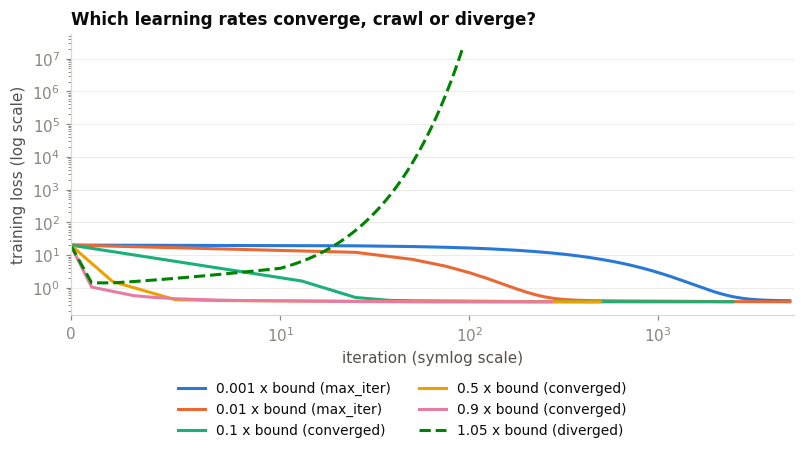

In [11]:
# The same sweep as loss curves.
show(plots.plot_lr_sweep(p1))

item,value
stop reason,converged
iterations,496
final loss,0.373581
gradient norm at the end,9.841e-07 (tolerance 1e-06)


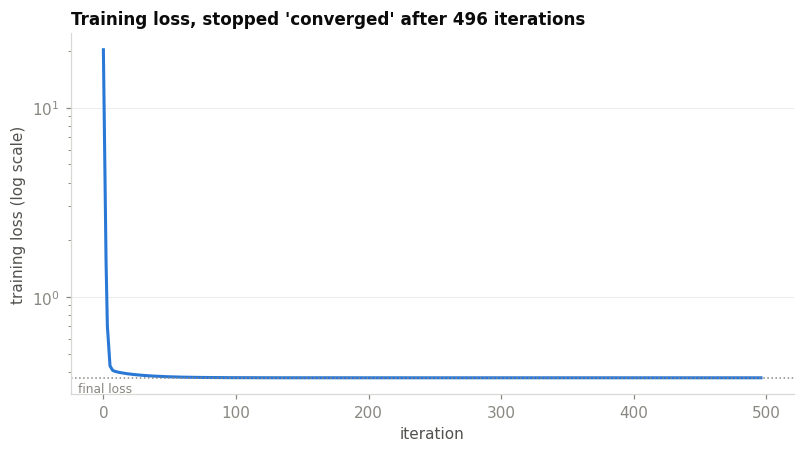

In [12]:
# How the final run ended, and its loss curve.
display(view.p1_fit(p1))
show(plots.plot_loss_curve(p1))

In [13]:
# Correctness: the exact least-squares solution is the reference that gradient descent should reach.
view.p1_oracle(p1)

item,value
reference,"oracle: np.linalg.lstsq, used only to check GD"
largest weight difference,5.016e-06
loss gap (GD minus exact),1.115e-11
validation R² difference,9.284e-10
gradient check at zeros (max relative error),7.765e-07
gradient check at a random point,5.308e-08


### Justification: back-transform

The inverse transform of an average is not the average count: without a correction the model's predictions are 0.919 of the true mean on validation. We compared two options, each fitted on the training rows and judged on validation: no factor (R² 0.7278) and a least-squares factor s = Σ(cnt+1)·q / Σq² = 1.069, the single multiplier of q = (λz + 1)^(1/λ) that minimises squared error on bikes (R² 0.7361, mean ratio 0.983). We keep the least-squares factor. In our first pass, with the log target, we also tried Duan's smearing factor, the textbook correction for a log model: it lowered validation R² from 0.718 to 0.696, because the large log-errors sit in quiet night hours while the factor inflates the peaks. Duan's factor is defined for the log only, so it is not in this table. The method is fixed for every later phase; each phase recomputes the factor from its own training residuals.

In [14]:
# The two back-transform options, each fitted on the training rows and judged on the validation rows.
view.p1_backtransform(p1)

method,factor,mean ratio (validation),validation R²,validation RMSE
least-squares factor,1.0693,0.9830,0.7361,94.6902
no factor,1.0000,0.9189,0.7278,96.1509


### Justification: target transform

We fit z = ((cnt + 1)^λ − 1) / λ with λ = 0.1. This family runs from the logarithm (λ → 0) to the raw count (λ = 1); predictions come back to bikes through the inverse, (λz + 1)^(1/λ) − 1.

- **Why not the log.** Our first complete run used `log1p(cnt)` (it is kept in the git history under the tag `v1-submitted`). On the log scale an error of four bikes at 3 am weighs as much as an error of two hundred at 5 pm, but R² on bikes is decided by the busy hours. The log fit spent its effort in the wrong place.
- **Why not the raw count.** At λ = 1 the model is additive in bikes, and the multiplicative structure of the data (a busy hour on a growing system in good weather) is lost: validation R² falls to 0.694.
- **What the table below shows for this phase.** With the Phase 1 design, validation R² is 0.7212 for the log, 0.7361 at λ = 0.1, 0.7414 at 0.2, 0.7416 at 0.3 and 0.7340 at 0.5. Taken alone, this phase would choose λ = 0.3.
- **Why we use 0.1 anyway.** The transform has to be the same in every phase, otherwise Phase 2 could not start from Phase 1's weights. The best exponent shrinks as the model gains structure: a simple model needs a milder transform to make up for what it cannot express, a richer one does not. Our first pass and the pilot fits after it showed that the model the chain ends with prefers about 0.1, so that is the value we fix here, giving up about 0.005 of R² in this phase. Phase 3 checks the exponent again on its target design; if that check disagreed with 0.1 we would have to restart the chain.
- **Honesty note.** This choice was made from a full earlier run, not from this phase alone. We say so because the brief asks for our expectations to be written first: the second-pass Expectation cell above was committed before this run.

exponent,iterations,stop reason,train R²,validation R²,validation RMSE
0.0000,474,converged,0.7293,0.7212,97.3189
0.05000,485,converged,0.7394,0.7302,95.7299
0.1000,496,converged,0.7462,0.7361,94.6902
0.1500,507,converged,0.7506,0.7396,94.0566
0.2000,518,converged,0.7532,0.7414,93.7259
0.3000,540,converged,0.7548,0.7416,93.6934
0.5000,585,converged,0.7496,0.7340,95.0559
1.0000,699,converged,0.7140,0.6939,101.9651


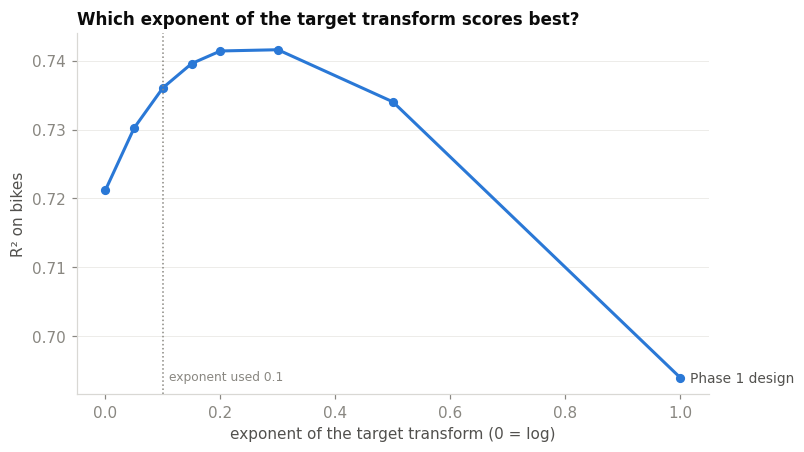

In [15]:
# The same design under each candidate exponent of the target transform (0 = log, 1 = raw counts).
display(view.p1_target_power(p1))
show(plots.plot_target_power(p1))

In [16]:
# Scores of the Phase 1 model on the training and validation rows.
view.p1_scores(p1)

,R²,RMSE,R² on the target z
train,0.7462,90.8506,0.8358
validation,0.7361,94.6902,0.8234


In [17]:
# Three ways to encode the hour of day.
view.p1_hour_encoding(p1)

hour encoding,weights,validation R²,iterations,stop reason
six sine/cosine pairs,25,0.7294,201,converged
hour as a number,14,0.2604,201,converged
one-hot dummies,36,0.7361,–,–


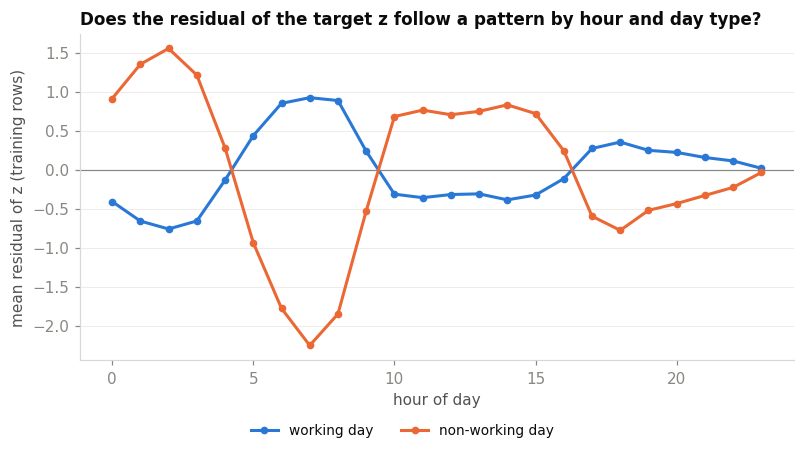

In [18]:
# What is left over: the residuals by hour and day type.
show(plots.plot_residual_profile(p1))

### Justification: bonus

**The operator's cost.** Under-predicting by some amount costs three times as much as over-predicting by the same amount. We read this as a weighted squared error on bikes (the cost is paid in bikes, not on the transformed scale):

L(w) = (1/n) Σ cᵢ (ŷᵢ − yᵢ)², with ŷᵢ = q(xᵢ·w) − 1, q(η) = (λη + 1)^(1/λ), and cᵢ = 3 if ŷᵢ < yᵢ, else 1.

**Gradient.** By the chain rule, ∂ŷᵢ/∂w = q′(ηᵢ)·xᵢ with q′(η) = (λη + 1)^(1/λ − 1) = q(η)^(1−λ), so ∇L = (2/n) Σ cᵢ (ŷᵢ − yᵢ) q(ηᵢ)^(1−λ) xᵢ. (For the log, λ → 0, this is the familiar exp(η)·xᵢ.) The weight cᵢ jumps only where the residual is zero, so it adds nothing to the gradient. Our finite-difference check agrees to 4.7e-09.

**Optimiser.** This loss is no longer a quadratic, so the fixed-step bound of the MSE model does not apply. We keep plain gradient descent but choose each step by backtracking (halve the step until the loss decreases enough), starting from the Phase 1 MSE weights. It stopped as "converged" after 2300 iterations. The absolute-error version of the same cost is shown in the table as a sensitivity check. This model is a side study: Phase 2 receives the MSE weights.

In [19]:
# The bonus: a model that fears under-prediction three times as much, against the plain model.
view.p1_bonus(p1)

model,squared cost,absolute cost,share under-predicted,mean error,R²,RMSE,mean prediction
MSE model,22106.7040,140.8221,0.5041,-15.5270,0.7278,96.1509,175.9138
asymmetric model,14007.3416,102.7505,0.3090,34.0833,0.7064,99.8598,225.5240


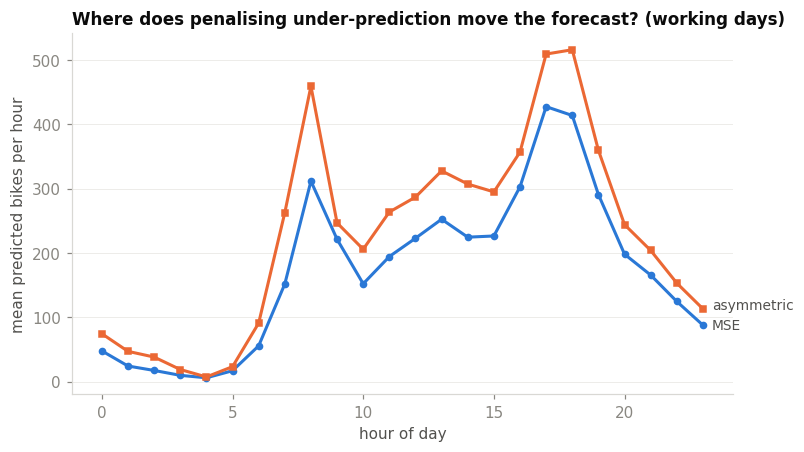

In [20]:
# Where the asymmetric cost moves the predictions.
show(plots.plot_bonus_shift(p1))

In [21]:
# The asymmetric loss and its gradient as implemented.
show_source(asym_loss, asym_grad)

def asym_loss(X, y, w, target: Target, k=3.0, cap=None):
    """L(w) = (1/n) sum_i c_i r_i^2 with r = q(Xw) - 1 - y."""
    r = target.q(_eta(X, w, y, target, cap)) - 1.0 - y
    return float(np.mean(_cost_weights(r, k) * r ** 2))

def asym_grad(X, y, w, target: Target, k=3.0, cap=None):
    """grad L = (2/n) X^T (c * r * dq/deta); shape (p,).

    The chain rule through q gives the dq/deta factor (exp(Xw) for the log). The weight switch has no
    derivative term because r = 0 exactly where c changes.
    """
    eta = _eta(X, w, y, target, cap)
    r = target.q(eta) - 1.0 - y
    return 2.0 / len(y) * (X.T @ (_cost_weights(r, k) * r * target.dq_deta(eta)))



**A control for the bonus.** The comparison above changes two things at once: the bonus model is fitted on bikes
instead of on the transformed scale, *and* it weights under-predictions three times. To separate them we fit the same bike-scale
loss with k = 1 (no asymmetry), from the same starting weights. Fitting on bikes alone already moves the mean
prediction up by a factor 1.089 (a fit on a transformed scale aims near the median, a
bike-scale fit at the mean) and lowers the share of under-predicted hours from
0.50 to 0.43. The asymmetry itself
adds a further factor 1.178 and brings the share down to
0.31. So of the total shift of 1.28, roughly two
thirds is the operator's asymmetry and one third is the change of scale. (The k = 1 model also has the best plain
RMSE of the three, 90.6, for this additive design: squared error on bikes is what
RMSE measures. The table's "MSE model" is the Phase 1 model without a back-transform factor, RMSE
96.2; with the factor it is 94.7.)

In [22]:
# The control for the bonus: the same bike-scale loss without the asymmetry (k = 1).
control = bonus_control.run(CFG)   # side study: reads artifacts/p1.json, writes artifacts/bonus_control.json
view.p1_bonus_control(p1, control)

model,squared cost,absolute cost,share under-predicted,mean error,RMSE,mean prediction
Phase 1 (z-scale MSE),22106.704,140.822,0.504,-15.527,96.151,175.914
"bike-scale, k = 1",17600.131,120.860,0.427,0.042,90.573,191.483
"bike-scale, k = 3",14007.342,102.751,0.309,34.083,99.860,225.524


## Outcome — Phase 1

**What happened.**
- Gradient descent converged in 496 iterations at lr = 0.5064 (λ_max 1.975, as expected close to 2). The weights differ from the closed-form solution by at most 5.0e-06 and the gradient check agrees to 7.8e-07.
- Validation R² is 0.7361 (95% interval 0.712–0.759), RMSE 94.7 bikes; training R² is 0.7462, so there is essentially no gap, as expected for 36 weights. With the log target of our first pass the same model scored 0.7212.
- The residual plot shows the pattern we predicted in both passes: on non-working days the model is far too low at night and too high at commute hours, because it has one hour profile for both day types.
- Bonus: with the 3:1 cost the mean prediction rises by a factor of 1.28; the share of under-predicted validation hours falls from 0.50 to 0.31 and the asymmetric cost from 22107 to 14007, while plain RMSE worsens from 96.2 to 99.9.

**What surprised us.**
- *First pass:* Duan's factor, the textbook correction, was the worst option, and the log target itself turned out to be the main weakness of our whole first chain. We only saw that after Phase 3, which is why there is a second pass.
- *Second pass, expectation met:* validation R² rose to about 0.735 as predicted, the learning rate is unchanged because the design matrix is the same, and the exponent table peaks at 0.3 for this simple model, above the 0.1 we use.
- *Second pass, expectation wrong:* we predicted that the back-transform factor would move closer to 1 with the milder transform. It moved away, to 1.069 from 1.041. Without a factor the predictions are still only 0.92 of the true mean, about the same as with the log, so the milder transform did not reduce the under-shoot of the mean as we had assumed; we do not have a cleaner explanation than that for this additive model.
- The hour as a plain number is still hopeless (R² 0.26): no transform makes a straight line through 0–23 follow a day with two peaks.
- The plain model, read without its factor, under-predicts about half of the hours (0.50) but is -16 bikes low on average: a fit on a transformed scale aims near the median, and the mean of a skewed count is higher. For an operator who fears empty docks the "neutral" model is already biased the wrong way.

**Handed to Phase 2:** the weight vector, the scaler, the target exponent, lr rule and stopping rule in `artifacts/p1.json`.

## Expectation — Phase 2: Polynomial Regression

*Written before running the phase (see the git history of this file).*

**What we do.** We load the Phase 1 weight vector from `artifacts/p1.json`, expand the design, and continue our own gradient descent from those weights (new columns start at zero).

**What we expect, and why.**

1. *The chain.* Because the 35 base columns keep the Phase 1 scaler and every new weight starts at zero, the very first loss of Phase 2 must equal the last loss of Phase 1 to about 1e-9. If it does not, the hand-over is broken.
2. *Which terms matter.* The degree-2 products `workingday × hour` (23 columns) should give by far the largest gain, because they let the hour profile differ between working and non-working days. We expect validation R² to rise from Phase 1's level to about 0.89 from this block alone.
3. *Powers.* Demand rises with temperature and then flattens, and falls with humidity, so squares and cubes of `temp` and `hum` should add a little more (about +0.02). We expect powers of `windspeed` to add nothing measurable. We do not expand `trend`: a power of time would extrapolate badly.
4. *Degree.* We expect the curve of validation R² against degree to flatten after degree 2 or 3; degree 4 should not beat degree 3 by more than 0.001. Our rule, fixed in advance, is to take the smallest degree within 0.001 of the best.
5. *Optimisation.* Powers of a variable are correlated with each other and the interaction columns are correlated with the hour dummies, so the expanded design is worse conditioned. We expect roughly ten times more iterations than Phase 1 (a few thousand) at the same "half the bound" learning rate, still with a monotone loss.
6. *Fit quality.* Training and validation R² should stay within about 0.01 of each other: 60–70 weights are still few for 8,708 rows. If so, this model is more likely under-fit than over-fit, which is the question for Phase 3.

## Expectation — Phase 2, second pass

*Written before re-running the chain with the power target (λ = 0.1). The cell above is unchanged.*

1. *The chain* must hold exactly as before: first Phase 2 loss equal to the last Phase 1 loss.
2. *Choices.* We expect the same answers as in the first run: the working-day × hour block carries almost all of the
   gain, degree 3, powers of `temp` only. If the degree or the columns change, it will be by a margin near our 0.001
   tolerance.
3. *Accuracy.* About 0.918 on validation (0.910 with the log target).

### Justification: initialisation from Phase 1
The expanded design keeps the 35 Phase 1 columns in the same positions and with the Phase 1 scaler (read from `artifacts/p1.json`, not refitted). Each new column gets its own training mean and standard deviation. The longer weight vector is the Phase 1 vector with zeros in the new positions. A zero weight switches a column off, so the expanded model starts as exactly the Phase 1 model: its first loss must equal Phase 1's last loss. The cell below checks this to 1e-9. Starting there instead of at random also means gradient descent only has to learn the correction that the new columns allow.

In [23]:
# Phase 2 starts from the Phase 1 weights, so its first loss must equal Phase 1's last loss (the hand-over).
import src.phases.p2 as p2mod
from src.poly import lift_weights

p2 = phase("p2", p2mod.run, CFG, upstream="p1", live=True, recompute_all=RECOMPUTE_ALL)   # reads artifacts/p1.json, fits Phase 2 here and now
assert abs(p2["init_loss"] - p1["train_loss_final"]) <= 1e-9, "the hand-over from Phase 1 to Phase 2 is broken"
view.p2_handover(p1, p2)

p2: computed live just now; largest relative difference to the stored artifact 0.0e+00, 0 other entries differ; stored file kept so that the later phases stay valid


item,value
Phase 1 final training loss,0.3735811984758046
Phase 2 initial loss,0.3735811984758046
difference,0.0000
hand-over check (|difference| <= 1e-9),passed


In [24]:
# How the Phase 1 weights are placed into the longer Phase 2 vector.
show_source(lift_weights)

def lift_weights(w_small, names_small, names_big):
    """Place the P1 weights in their slots of the bigger design, zeros elsewhere.

    w_small (p_small,), names_small / names_big are column-name lists.
    Returns w_big (p_big,) with w_big[names_big.index(name)] = w_small[i].
    Because the extra columns start at weight 0, the initial P2 loss equals the final P1 loss.
    """
    slot = {name: j for j, name in enumerate(names_big)}
    missing = [name for name in names_small if name not in slot]
    assert not missing, f"names missing from the big design: {missing}"
    w_big = np.zeros(len(names_big), dtype=np.float64)
    for i, name in enumerate(names_small):
        w_big[slot[name]] = w_small[i]
    return w_big



### Justification: what we expanded
We expand only where Phase 1's residuals showed structure.
- **`workingday × hour` (23 degree-2 products).** The Phase 1 residuals differ by day type at almost every hour. Without this block the expanded model reaches only 0.7499 on validation; with it 0.9178 (ablation below). This is the one expansion that matters.
- **Powers of `temp`.** Demand rises with temperature and flattens when it is hot. At the chosen degree, powers of `temp` alone give 0.9178, adding `hum` gives 0.9181 and adding `windspeed` as well gives 0.9180. Differences below 0.001 are far inside the noise of our validation set (standard error 0.0049), so by our rule we keep the smallest set: `temp` only.
- **Not expanded.** Hour dummies, weather dummies and `holiday` are 0/1, so their powers are themselves. `trend` is not raised to a power, because a polynomial in time bends away sharply outside the observed dates. The day-of-year terms are already non-linear.

In [25]:
# The expanded design: which blocks and power columns, how many new columns, and how hard it is to optimise.
view.p2_design(p2)

item,value
blocks,wd_x_hr
power columns,temp
columns,61 (25 new)
first new columns,"temp^2, temp^3, workingday*hr_1, workingday*hr_2, workingday*hr_3, workingday*hr_4 ..."
λ_max,2.7396
learning rate,0.3650
condition number,64.2255


### Justification: degree
"Degree" is the highest total degree of any term: the interaction products are degree 2 and the powers go up to the chosen degree. With every candidate fitted by our own gradient descent from the Phase 1 weights, validation R² is 0.9045 at degree 1 (interactions only), 0.9144 at degree 2, 0.9180 at degree 3 and 0.9180 at degree 4. Our rule, fixed before the run, is the smallest degree within 0.001 of the best: degree 3. The square captures "warmer is better", the cube captures the flattening at high temperature; a fourth power adds nothing. The learning rate is again half the stability bound, recomputed for this design (λ_max 2.740, lr 0.3650), with the same stopping rule as Phase 1.

In [26]:
# Validation R² for each candidate degree (the highlighted row is our choice).
view.p2_degree_sweep(p2)

degree,weights,iterations,stop reason,train R²,validation R²
1,59,458,converged,0.9055,0.9045
2,62,494,converged,0.9176,0.9144
3,65,697,converged,0.9216,0.9180
4,68,815,converged,0.9219,0.9180


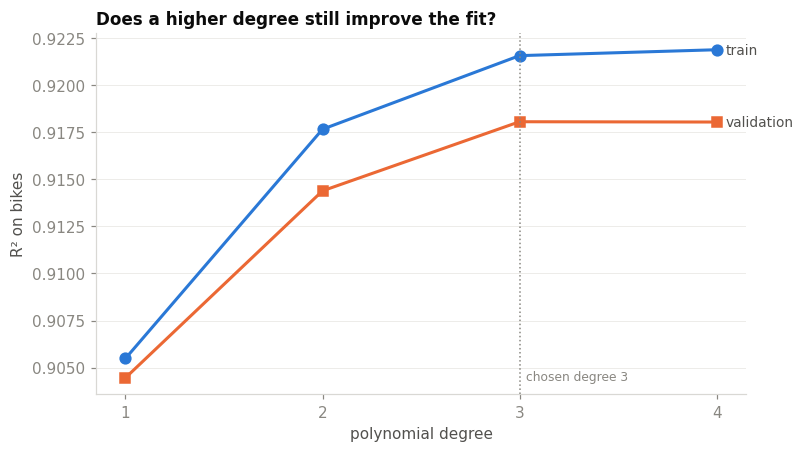

In [27]:
# The same sweep as a plot.
show(plots.plot_degree_sweep(p2))

In [28]:
# Which variables get powers: temperature alone, or humidity and wind as well.
view.p2_power_cols(p2)

power columns,weights,iterations,stop reason,train R²,validation R²
temp,61,636,converged,0.9206,0.9178
"temp, hum",63,668,converged,0.9218,0.9181
"temp, hum, windspeed",65,697,converged,0.9216,0.9180


In [29]:
# What the working-day x hour block adds.
view.p2_ablation(p2)

model,weights,train R²,validation R²
without the workingday x hour block,38,0.7612,0.7499
with the block,61,0.9206,0.9178


In [30]:
# Phase 2 against Phase 1 on the validation rows, and how the run ended.
display(view.p2_scores(p1, p2))
display(view.p2_fit(p2))

,R²,RMSE
Phase 1,0.7361,94.6902
Phase 2,0.9178,52.8411


item,value
stop reason,converged
iterations,636
largest weight difference to the closed-form solution,4.771e-06


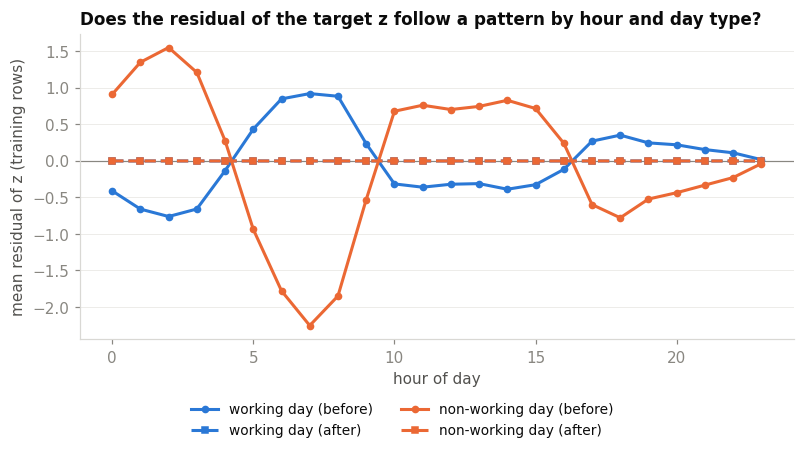

In [31]:
# The residuals by hour and day type before (Phase 1) and after (Phase 2) the expansion.
show(plots.plot_residual_profile(p1, p2))

## Outcome — Phase 2

**What happened.**
- The hand-over held exactly: the first Phase 2 loss equals the last Phase 1 loss (0.373581).
- Chosen model: degree 3, powers of `temp`, plus `workingday × hour`: 61 weights. Validation R² rose from 0.7361 to 0.9178 (gain 0.182, paired 95% interval 0.161–0.206); RMSE is 52.8 bikes. Training R² is 0.9206: still no gap.
- As expected, almost all of the gain is the interaction block (degree 1 with interactions already gives 0.9045); the temperature powers add about 0.02, and the curve is flat after degree 3.
- The residual profile by hour and day type is now flat.

**What surprised us.**
- Optimisation was much easier than we feared: 636 iterations, not thousands. We had expected the new columns to be strongly correlated with the old ones, but because we build powers and products from standardised columns the condition number only rose to 64.
- Humidity powers were not worth keeping (0.9178 → 0.9181); we had expected humidity to need a curve as much as temperature does.
- Training and validation R² are almost identical. A model that fits unseen rows as well as its own training rows is not over-fit; the open question for Phase 3 is whether it is still too simple.

**Second pass.** With the power target the choices are the ones we expected: the same block, the same degree, powers of `temp` only, and validation R² 0.9178 against 0.9105 with the log target. One detail differs from the first pass: the degree curve is not quite as flat before degree 3 (0.9144 at degree 2, 0.9180 at degree 3), so the cube of temperature earns its place more clearly now.

**Handed to Phase 3:** degree 3 and the expanded feature list in `artifacts/p2.json`.

## Expectation — Phase 3: Bias–Variance Tradeoff

*Written before running the phase (see the git history of this file).*

**What we do.** We take the Phase 2 design (its degree and feature list, loaded from `artifacts/p2.json`) as the anchor and move complexity both below and above it on a nested ladder of ten designs, from "no hour information" (13 weights) up to "month × working day × hour" (about 900 weights). We also vary the pure polynomial degree, and the amount of training data. Every design is scored three ways: on our seeded validation set, on whole held-out days inside the training portion, and on one chronological split (train before 1 July 2012, validate after).

**What we expect, and why.**

1. *Phase 2 is not over-fit.* Its training and validation R² should differ by less than 0.01. If anything we expect it to be slightly under-fit: letting the weather effect depend on the hour should still raise validation R² by 0.01–0.02.
2. *Degree alone will look flat.* Raising the power of temperature and humidity from 3 to 8 should move neither curve by more than 0.002. A flat line is not evidence of a good fit, which is why we need the wider ladder.
3. *Variance appears late.* On the ladder we expect validation R² to peak somewhere around 250–450 weights and then fall while training R² keeps rising. The first clearly harmful levels should be the month × hour blocks, where many cells hold only a handful of training rows.
4. *Learning curves.* At Phase 2 complexity, validation R² should stop improving after roughly half the training days (a bias signature). At the top of the ladder the train–validation gap should be visibly wider with little data and shrink as data is added (a variance signature).
5. *The time question.* We expect the seeded estimate and the held-out-day estimate to be almost equal (within 0.005). Our model has no way to memorise a particular day, so sharing days between training and validation should hardly help it. The chronological estimate should be clearly lower, by 0.04–0.08, because the model has to extrapolate a growth trend into six months it has never seen, having observed July–December only once.
6. *Which estimate to trust.* For the hidden test set, which is the 20th of each month and so lies inside the observed period, the held-out-day estimate is the right one. For genuinely future months the chronological estimate is the honest one. We expect the diagnosis to stay "bias first, variance only at the top of the ladder" under all three, but the chronological split should prefer a simpler model than the seeded split does, especially disliking the blocks that let the trend vary by hour.

## Expectation — Phase 3, second pass

*Written before re-running the chain with the power target (λ = 0.1). The cell above is unchanged; the ladder now has
eleven levels because level C6 was added during the first pass.*

1. *Diagnosis.* Unchanged in kind: Phase 2 under-fit, target at level C6, variance only at the top of the ladder.
2. *The time question.* This is where we expect the real change. With the log target the chronological estimate of the
   target was about 0.91 against 0.94 on held-out days. A straight trend on the log scale is exponential growth; on the
   λ = 0.1 scale it grows more slowly, so the overshoot in the later months should shrink and the chronological
   estimate should rise to about 0.93 to 0.94, almost closing the gap.
3. *Held-out days.* A smaller gain, about +0.003 to +0.004 for the target.
4. *Exponent check.* A new table scores the target design for several exponents. We expect a flat optimum around 0.1
   on validation and held-out days, with 0.15 to 0.2 slightly better chronologically. If the best exponent were far
   from the one Phase 1 used, our chain would be inconsistent and we would have to start again.

### Justification: what we varied

- **A ladder of nested designs, anchored at Phase 2.** Level C3 is exactly the Phase 2 design, read from `artifacts/p2.json`. Below it we remove what Phase 2 added (C2: no powers; C1: no interactions; C0: no hour at all). Above it we add blocks: weather effects that depend on the hour (C4), a separate hour profile for each weekday (C5), weather detail and weather memory (C6, see the note below), finer weather interactions (C7), hour-specific season and trend (C8), and finally month × hour and month × day type × hour (C9, C10), where many cells contain only a few training rows. Bias shows as "training and validation both low, both rise when we add a block"; variance shows as "training keeps rising, validation falls".
- **The degree alone**, from 1 to 8, with everything else as in Phase 2, because the task asks about the degree; we expected this axis to be flat.
- **The amount of training data** (10% to 100% of the training days) for the anchor, the target and the top level: more data cures variance but not bias.
- **Three ways of scoring** each design: the seeded validation set; five folds of whole held-out days inside the training portion (folds are fixed by the calendar, not by a random seed); and one chronological split.
- **How the sweeps are fitted.** These several hundred fits use the closed-form least-squares solution, which our gradient descent reaches to within 1e-5 in Phases 1 and 2 (the chain cell below checks it again on the anchor); the largest levels would need tens of thousands of iterations each. A tiny ridge term (1e-8) keeps the solution defined where columns are exact copies of each other (`holiday` is determined by the weekday dummies and `workingday`).
- **Note on level C6.** This level was not in our first ladder. After the first complete run we looked at where the C5 model's errors were (working-day rush hours and rainy hours carried about half and a fifth of the squared error) and added the terms that address them: squares and cubes of humidity, wind terms, a temperature effect per working-day hour, and the weather situation one hour earlier and the worst of the previous three hours (wet roads keep riders away after the rain has stopped). These last columns use the weather of neighbouring rows, never their counts. Because this level was designed after looking at validation errors, we judge it mainly by the two estimates that were not used to design it.

In [32]:
# Phase 3 builds a ladder of designs on top of the Phase 2 artifact and scores each one three ways.
from src import plots_p3
from src.phases import p3 as p3mod

p3 = phase("p3", p3mod.run, CFG, upstream="p2", live=True, recompute_all=RECOMPUTE_ALL)   # runs Phase 3 here and now (about 15 seconds)

p3: computed live just now; largest relative difference to the stored artifact 0.0e+00, 0 other entries differ; stored file kept so that the later phases stay valid


In [33]:
# The chain: the anchor is exactly the Phase 2 design, and our closed-form fit must reproduce its validation R².
view.p3_chain(p2, p3)

item,value
Phase 2 degree,3
Phase 2 features (with bias),61
Phase 2 power columns,temp
Phase 2 blocks,wd_x_hr
Phase 2 validation R² (gradient descent),0.91780
anchor validation R² (closed form here),0.91780
anchor check (closed form minus gradient descent),-3.872e-08
back-transform method reused from Phase 1,ls


In [34]:
# The complexity ladder, with the three validators for every level (the highlighted row is the target level).
view.p3_ladder(p3)

level,weights,train R²,validation R²,gap,held-out days R²,held-out days sd,chronological R²
C0_no_hour,13,0.2560,0.2415,0.01452,0.2496,0.02777,0.1264
C1_additive,36,0.7462,0.7361,0.01014,0.7439,0.01143,0.6436
C2_wd_x_hr,59,0.9055,0.9045,0.00103,0.9032,0.01146,0.8369
C3_phase2,61,0.9206,0.9178,0.00278,0.9180,0.01323,0.8941
C4_hr_x_weather,107,0.9285,0.9259,0.00264,0.9249,0.01351,0.9123
C5_weekday_x_hr,251,0.9381,0.9346,0.00348,0.9327,0.01123,0.9202
C6_weather_detail,282,0.9506,0.9413,0.00931,0.9462,0.00772,0.9378
C7_fine_weather,332,0.9513,0.9407,0.01058,0.9459,0.00732,0.9283
C8_hr_x_time,401,0.9520,0.9418,0.01015,0.9458,0.00769,0.9041
C9_month_x_hr,665,0.9534,0.9401,0.01326,0.9436,0.00816,0.8865


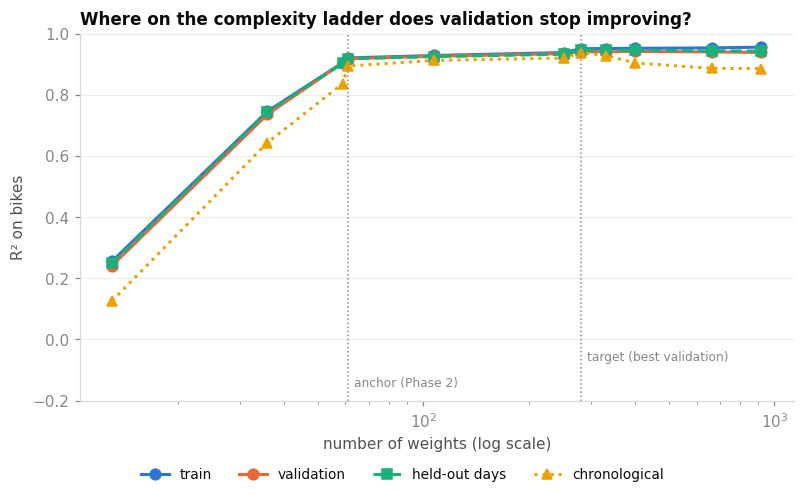

In [35]:
# The same ladder as a plot.
show(plots_p3.plot_ladder(p3))

In [36]:
# The degree axis alone: anchor blocks and power columns fixed, only the degree changes.
view.p3_degree_axis(p3)

degree,weights,train R²,validation R²,held-out days R²,chronological R²
1,59,0.9055,0.9045,0.9032,0.8369
2,60,0.9157,0.9137,0.9131,0.8729
3,61,0.9206,0.9178,0.9180,0.8941
4,62,0.9210,0.9174,0.9183,0.8994
5,63,0.9210,0.9170,0.9183,0.8995
6,64,0.9211,0.9170,0.9184,0.8990
8,66,0.9212,0.9170,0.9181,0.8946


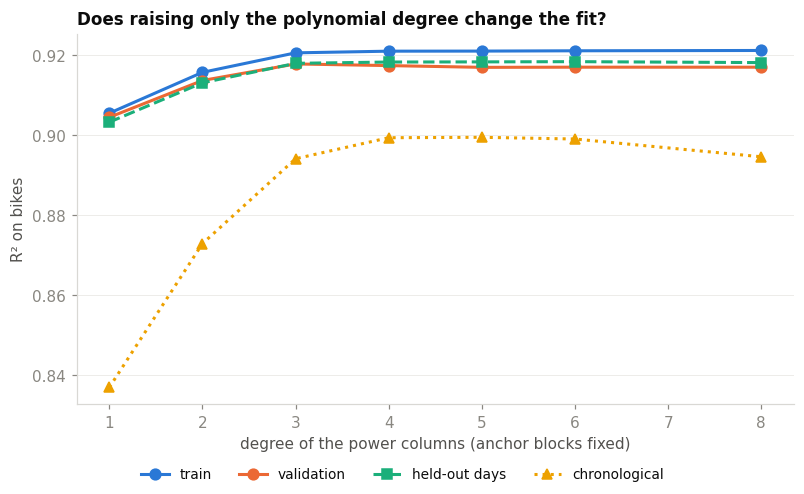

In [37]:
# The degree axis as a plot.
show(plots_p3.plot_degree_axis(p3))

In [38]:
# Learning curves for the anchor, the target and the top of the ladder.
view.p3_learning_curves(p3)

design,share of training days,days,rows,train R²,validation R²
anchor,0.1000,46,873,0.8955,0.9090
anchor,0.2000,91,1729,0.8958,0.9118
anchor,0.4000,182,3441,0.9096,0.9175
anchor,0.6000,274,5210,0.9133,0.9170
anchor,0.8000,365,6939,0.9189,0.9173
anchor,1.0000,456,8708,0.9206,0.9178
target,0.1000,46,873,0.9414,0.8971
target,0.2000,91,1729,0.9360,0.9200
target,0.4000,182,3441,0.9391,0.9336
target,0.6000,274,5210,0.9450,0.9388


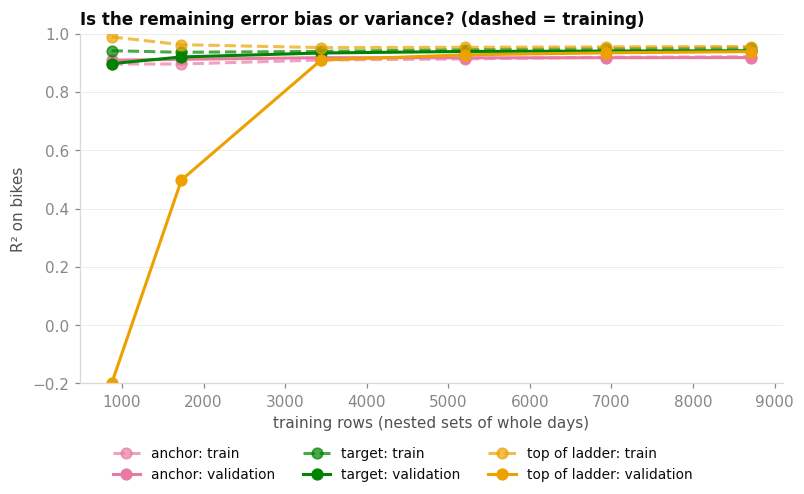

In [39]:
# The learning curves as a plot.
show(plots_p3.plot_learning_curves(p3))

### Justification: the chronological cut

We train on every date before 2012-07-01 (8151 rows) and validate on every date from then on (2735 rows, about a quarter of the file). We put the cut there for three reasons: the held-out part is about the same size as our seeded validation set, so the two estimates are comparably precise; it covers half a seasonal cycle (summer to winter) instead of one season; and the training part still contains one full year plus the first half of the second, so the model has seen each month at least once. A later cut would test only autumn and winter; an earlier one would leave too little of 2012 to learn the growth from.

In [40]:
# The anchor and the target scored by the seeded split, held-out days and the chronological split, with their gaps.
view.p3_estimates(p3)

design,validation R²,interval low,interval high,held-out days R²,held-out days sd,chronological R²,leakage gap,drift gap
anchor,0.9178,0.9081,0.9272,0.9180,0.01323,0.8941,-1.557e-04,0.02386
target,0.9413,0.9332,0.9489,0.9462,0.00772,0.9378,-0.00491,0.00838


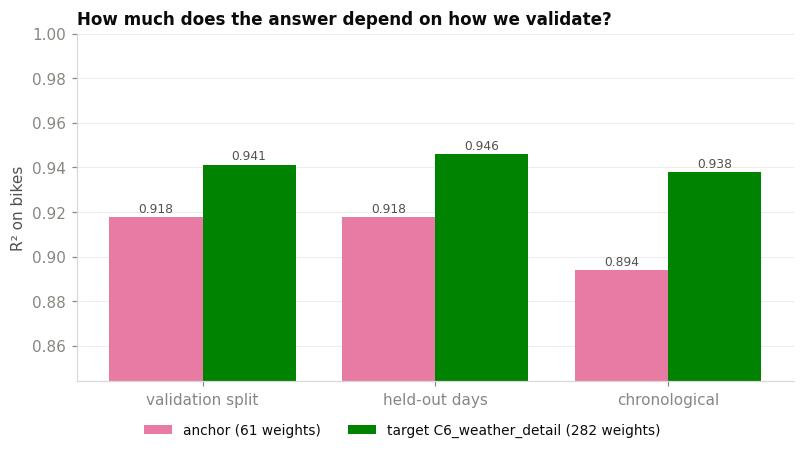

In [41]:
# The same estimates as a plot.
show(plots_p3.plot_three_estimates(p3))

### Justification: which estimate to trust

- **The gap has two possible causes, and we measured them separately.** Seeded versus held-out days isolates the effect of sharing days between training and validation: -0.0002 for the Phase 2 model and -0.0049 for the target (a negative number means held-out days score higher), both smaller than the spread between day folds (0.013). Held-out days versus chronological isolates what changes when the validation period lies in the future: 0.024 and 0.008.
- **So what gap there is, is drift, not leakage.** In the late period the mean demand is 262 bikes against 168 before the cut, and the Phase 2 model's predictions there are 1.08 times the true mean: a straight trend on the transformed scale still extrapolates growth too steeply. If we only correct that level (a diagnostic, not a usable score) R² rises to 0.909, so most of the gap is the level and the hourly shape still fits.
- **Which one to trust.** For data from new time periods, the chronological estimate (0.894 for Phase 2, 0.938 for the target) is the honest one, and it is the number we would quote to an operator planning next year. The seeded number is the easiest to flatter. For our hidden test set specifically, which is the 20th of each month inside the two observed years, the held-out-day estimate is the closest match.
- **Does it change the diagnosis?** No in kind, yes in degree: see the Outcome.

In [42]:
# Chronological detail: the late period has a much higher level of demand (growth) than the early one.
view.p3_chrono_detail(p3)

design,cut_date,mean_cnt_early,mean_cnt_late,mean_ratio,n_early,n_late,r2,r2_level_corrected,rmse
anchor,2012-07-01,167.7858,262.4695,1.0816,8151,2735,0.8941,0.9090,70.3407
target,2012-07-01,167.7858,262.4695,1.0624,8151,2735,0.9378,0.9447,53.8929


In [43]:
# How much variance is left once the design cells are fully known (an optimistic ceiling).
view.p3_noise_floor(p3)

item,value
n_cells,2636
noise_floor_r2,0.9547
noise_floor_r2_adjusted,0.9350
singleton_cell_share,0.2986
singleton_row_share,0.09038


In [44]:
# The diagnosis, and the complexity we carry forward.
view.p3_diagnosis(p3)

item,value
anchor_gap_train_val,0.00278
chrono_gain,0.04374
day_block_gain,0.02826
degree_axis_range,0.00414
gain_ci_hi,0.02983
gain_ci_lo,0.01767
gain_target_over_anchor,0.02350
label,under-fit
overfit_from_level,10
target,C6_weather_detail


### Justification: exponent check

Phase 1 fixed the exponent of the target transform at 0.1 for the whole chain, on the strength of an earlier run. Here we test that decision on the design this phase selects: the table and plot below refit the target design for each candidate exponent. On validation the best is 0.1; the neighbours score 0.9410 (0.05), 0.9413 (0.1) and 0.9405 (0.15), against 0.9390 for the log and 0.9231 for the square root. Held-out days agree (0.9426 for the log, 0.9462 at 0.1). The chronological split would like a slightly larger exponent (0.938 at 0.1, 0.941 at 0.15, 0.941 at 0.2) and dislikes the log most (0.914). Our consistency test is whether the exponent in use is within 0.001 validation R² of the best one: it is (True), so the chain does not have to be restarted. We do not move to 0.15 for the chronological gain: the exponent is tuned on the validation set like every other choice, and 0.1 is the best there.

exponent,validation R²,held-out days R²,chronological R²
0.0000,0.9390,0.9426,0.9141
0.05000,0.9410,0.9453,0.9297
0.1000,0.9413,0.9462,0.9378
0.1500,0.9405,0.9459,0.9411
0.2000,0.9390,0.9448,0.9412
0.3000,0.9345,0.9411,0.9356
0.5000,0.9231,0.9310,0.9148
1.0000,0.8879,0.8974,0.8439


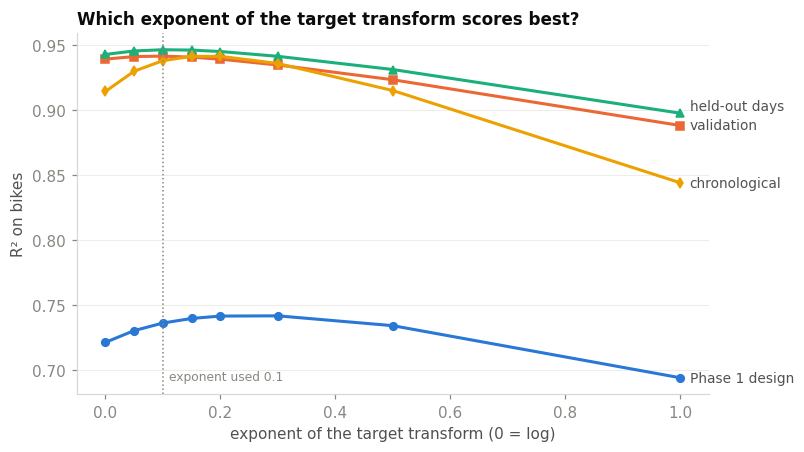

In [45]:
# The target design in closed form under each candidate exponent (the chain itself uses the exponent from Phase 1).
display(view.p3_exponents(p3))
show(plots.plot_target_power(p1, p3))

### Justification: target complexity

Rule: the simplest ladder level whose seeded validation R² is within 0.001 of the best level. It selects C6_weather_detail (282 weights): validation R² 0.9413 against 0.9346 one level below and 0.9407 one level above. The other two estimates agree: held-out days 0.9327 → 0.9462 → 0.9459, chronological 0.920 → 0.938 → 0.928.

We have to be open about two things. First, our original rule was "the level with the highest validation R²". On the first ladder it picked a level 140 weights larger than its neighbour on a difference of 0.0005, which is not a rule we could defend, so we replaced it with the same "smallest within 0.001 of the best" rule we had already fixed for the degree in Phase 2. Second, level C6 itself was added after that first run (see the note above). Both changes are in the git history, and the rule still looks only at the seeded validation set.

## Outcome — Phase 3

**Diagnosis: the Phase 2 model is under-fit (high bias, no measurable variance).**
- Its training and validation R² differ by 0.0028. A model that scores the same on rows it has and has not seen is not over-fit.
- Adding structure raises validation R² from 0.9178 to 0.9413: a gain of 0.023 with a paired 95% interval of 0.018–0.030, confirmed on held-out days (+0.028) and on the chronological split (+0.044). Something real was missing.
- The Phase 2 learning curve is nearly flat: with 10% of the training days validation R² is already 0.909, with all of them 0.918. More data does little for a model that is too simple.
- Variance does exist, but only at the top of the ladder: from level 10 on, training R² keeps rising (0.9558 at C10) while validation falls (0.9384); the chronological score starts falling much earlier, right after the target (0.938 at C6, 0.904 at C8, 0.886 at C10).
- The target itself shows a small gap (training 0.9506, validation 0.9413) and its learning curve is still rising at full size (0.940 with 80% of the days, 0.941 with all). That is where a little variance begins, and it is what Phase 4 has to watch.

**The time question.** Seeded 0.918, held-out days 0.918, chronological 0.894 for Phase 2; 0.941 / 0.946 / 0.938 for the target. Sharing days between training and validation is worth nothing to these models; what gap there is comes from drift, the later months having a higher level of demand than the trend predicts. We trust the chronological number for future periods. It does not change the diagnosis, the simpler models are worse on every split, but it does change how far we go: it is the split that punishes the levels above the target most clearly, so it supports stopping there.

**What surprised us.**
- *First pass:* we expected sharing days between training and validation to matter at least a little. It does not. The warning in the task statement is right in general, but a linear model with a few hundred weights has no way to recognise an individual day. (A tree model we tried outside the pipeline does: it scores 0.966 on the seeded split and 0.950 on held-out days. The leakage is real; our model class is simply too stiff to use it.)
- *First pass:* the degree axis moved validation R² by only 0.0041 between degree 2 and 8. Had we varied only the degree we would have concluded "reasonably fit" and missed 0.023 of R². Our own first selection rule failed on a near-tie, and our first ladder stopped one useful level short.
- *Second pass, expectation met:* the diagnosis and the target level are unchanged, and the exponent check confirms 0.1.
- *Second pass, better than expected:* we predicted the chronological estimate of the target would rise from 0.914 to about 0.93–0.94. It is 0.938, and the gap between held-out days and the chronological split shrank from 0.028 to 0.008. With the log, the model over-shot the later months by a factor 1.11; now by 1.06. Most of what we had called "drift" in the first pass was our own choice of target: a straight line on the log scale is exponential growth.
- *Second pass:* the gain on held-out days is the modest one we expected (0.9426 → 0.9462).

**How much is left.** Averaging `cnt` over cells of year, month, day type, hour and weather situation explains 0.935 of the training variance after adjusting for the number of cells; our target is above that benchmark on unseen rows. The diagnostic tree model mentioned above (`exp/v2/`, never used for any prediction we submit) scored about 0.950 on held-out days and about 0.90 chronologically, so the target (0.946 and 0.938) is within about 0.004 of a far more flexible model on unseen days and clearly ahead of it on unseen months. In a second exploration round we tried twenty more groups of input-only features on top of the target (daylight by hour, earlier temperature and humidity, rain in the last six hours, more hour × weather products, and others). None improved held-out days by more than 0.001, and the only ones that did anything, separate levels for each calendar month of each year, gained 0.003 on held-out days and lost 0.05 chronologically. We stop adding structure here.

**Handed to Phase 4:** diagnosis "under-fit", target complexity C6_weather_detail with 282 weights (degree 3). The model we carry forward is not over-fit, but it is the first one with a visible train–validation gap, so we expect regularization to act as insurance with at most a small gain; Phase 4 tests that, including on the over-fit top level.

## Expectation — Phase 4: Regularization (L1, L2, Elastic Net)

*Written before running the phase (see the git history of this file).*

**What we do.** We load the target complexity from `artifacts/p3.json`, add back the six columns we had kept out for conditioning reasons (`atemp`, `yr`, `instant`, `season`, `mnth`, `weekday`), and fit Ridge, Lasso and Elastic Net with our own solvers on exactly the same standardised design, the same training rows and the same grid density. For each method we pick the penalty by validation R² and then check that choice on held-out days and on the chronological split. Finally we judge every original column with drop tests, lasso selection frequency and correlations.

**What we expect, and why.**

1. *Regularization will be a robustness choice, not an accuracy one.* Phase 3 should hand us a model that is not over-fit, so we expect the best penalties to be small and all three methods to land within about ±0.002 validation R² of the unpenalised fit, which is inside the bootstrap noise. We do not expect any method to "win" clearly.
2. *Lasso will not be very sparse.* The signal here is spread over many hour-specific columns. We expect Lasso at its best penalty to keep well over half of the coefficients.
3. *Lasso will be unreliable on duplicates.* `temp` and `atemp` are correlated at 0.985. We expect Lasso to keep both at small penalties, or to pick one of them arbitrarily, and Elastic Net to share the weight between them. This is why a zero from Lasso is only one piece of evidence for us, next to the drop tests and the selection frequency over resampled days.
4. *Where the penalty should matter.* On the most complex ladder level, which Phase 3 should show to be over-fit, we expect a penalty to recover most of the lost validation R², but not to beat the target design by more than the noise.
5. *Column verdicts we predict.* Useful: `hr`, `temp`, `hum`, `weathersit`, and the day-type information. Redundant: `atemp` (carried by `temp`), `season` and `mnth` (carried by the day-of-year terms from `dteday`), `yr` and `instant` (carried by the trend from `dteday`), and at least one of `weekday` / `workingday` / `holiday`, since `workingday` is an exact function of the other two. We are least sure about `windspeed` and `holiday`: their effect may be too small to separate from noise, in which case the honest verdict is "uninformative".
6. *Surprise we are watching for.* If dropping a column we believe to be useful costs nothing, another column is carrying its information and we have the labels the wrong way round.

## Expectation — Phase 4, second pass

*Written before re-running the chain with the power target (λ = 0.1). The cell above is unchanged.*

1. *Regularization* should again be insurance: three methods tied within noise, tiny penalties, Lasso not sparse.
2. *Verdicts* should be the same as in the first pass, with one candidate for a flip: `windspeed` was useful by a
   small margin and could fall back to uninformative.
3. *Final model.* About 0.941 on validation, 0.946 on held-out days and 0.93 to 0.94 chronologically.

### Justification: search ranges and strategy

- **How Phase 3 shapes the search.** The diagnosis was "under-fit, no measurable variance" for the model we carry forward. So we do not expect a large penalty to help, and the grid has to reach down to practically zero to show that; we also add the unpenalised fit as a reference line. At the other end the grid must go far enough to show the model being destroyed. If a method's best penalty turns out to be the smallest value on its grid, we read that as "no penalty wanted" and say so, rather than as a finding about that particular value.
- **Design.** The Phase 3 target design plus the columns we had held back (`atemp`, `yr`, `instant`, `season`, `mnth`; `weekday` is already in the target), so that every original column is in front of the three methods. All columns are standardised on the training rows; the intercept is never penalised.
- **Objective.** (1/2n)‖y − b − Xw‖² + α·ρ‖w‖₁ + (α/2)(1 − ρ)‖w‖², with ρ = 0 for Ridge, ρ = 1 for Lasso and ρ in {0.1, 0.3, 0.5, 0.7, 0.9, 0.95} for Elastic Net. Ridge is solved in closed form; Lasso and Elastic Net by our own cyclic coordinate descent with soft-thresholding, warm-started along the path. Our tests check all three against a reference library to better than 1e-3.
- **Grids.** 40 log-spaced values per path. Ridge: 1e-06 to 1000. Lasso and Elastic Net: from the smallest penalty that sets every weight to zero (computed from the data: 0.835 for Lasso) down to one ten-thousandth of it. Log spacing because the effect of a penalty is multiplicative.
- **Honesty note.** 7 Lasso fits, all at one large grid value far from the chosen one, used the full 20000 sweeps without meeting our tolerance; the exactly duplicated columns in this design make coordinate descent crawl there. None of them is a chosen model.

In [46]:
# Phase 4 adds the held-back columns to the Phase 3 target design and runs our three solvers; it is the slowest phase, so the stored artifact is loaded when nothing upstream changed.
from src import plots_p4
from src.phases import p4 as p4mod
from src.regularization import cd_sweep, enet_cd_gram, ridge_closed_form, soft_threshold

p4 = phase("p4", p4mod.run, CFG, upstream="p3", recompute_all=RECOMPUTE_ALL)   # python run.py p4 recomputes it

loaded cached artifacts/p4.json (same config and upstream artifact); run `python run.py p4` or change CFG to recompute


In [47]:
# The chain: the target level from Phase 3, the candidate columns added, and the resulting width.
view.p4_design(p3, p4)

item,value
Phase 3 target level,C6_weather_detail
Phase 3 weights (with bias),282
design used here,C6_weather_detail
weights before candidates,282
candidates added,"c_atemp, c_yr, c_instant, c_season, c_mnth"
candidates skipped (already present),c_weekday
weights after candidates (with bias),299
back-transform method,ls
solver tolerance,1.000e-07
solver sweeps allowed,20000


In [48]:
# Baseline: the same design with a negligible penalty (closed-form least squares).
view.p4_unregularised(p4)

item,value
penalty λ,1.000e-08
train R²,0.95027
train RMSE,40.21
validation R²,0.93926
validation RMSE,45.43


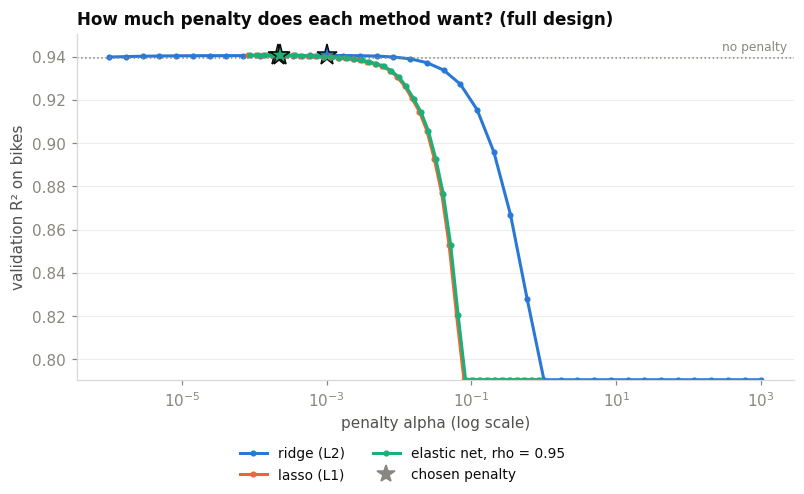

In [49]:
# How the validation R² of each method moves with the penalty.
show(plots_p4.plot_validation_curves(p4))

In [50]:
# The penalty each method chose (best validation R², ties go to the larger penalty), and the elastic-net ratios.
display(view.p4_methods(p4))
display(view.p4_enet_ratios(p4))

method,penalty λ,l1 ratio,validation R²,interval low,interval high,held-out days R²,held-out days s.e.,chronological R²,non-zero weights,out of
elastic net,2.261e-04,0.9500,0.94063,0.93229,0.94830,0.94515,0.00345,0.92931,285,298
lasso (L1),2.148e-04,1.0000,0.94063,0.93229,0.94830,0.94516,0.00345,0.92932,285,298
ridge (L2),1.000e-03,0.0000,0.94052,0.93229,0.94810,0.94498,0.00348,0.92890,298,298


l1 ratio,best validation R²,best penalty
0.1000,0.94056,1.058e-03
0.3000,0.94060,5.654e-04
0.5000,0.94062,4.296e-04
0.7000,0.94063,3.068e-04
0.9000,0.94063,2.387e-04
0.9500,0.94063,2.261e-04


In [51]:
# Our solvers: closed-form Ridge, and one sweep of coordinate descent with soft-thresholding, which is the whole of Lasso and Elastic Net.
show_source(soft_threshold, ridge_closed_form, cd_sweep, enet_cd_gram)

def soft_threshold(z, t):
    """S(z, t) = sign(z) * max(|z| - t, 0)."""
    return np.sign(z) * max(abs(z) - t, 0.0)

def ridge_closed_form(X, y, alpha):
    """Solve (G + alpha I) w = c with G = Xc'Xc/n, c = Xc'yc/n.  Returns (b, w).

    Equals sklearn Ridge(alpha = n * alpha).
    """
    G, c, x_mean, y_mean = centred_gram(X, y)
    w = np.linalg.solve(G + alpha * np.eye(G.shape[0]), c)
    return intercept(x_mean, y_mean, w), w

def cd_sweep(G, c, w, q, alpha, l1_ratio):
    """One cyclic pass over the coordinates, updating w and q = G w in place.

    w_j <- S(z_j, alpha*rho) / (G_jj + alpha*(1-rho)),  z_j = c_j - q_j + G_jj w_j.
    Returns the largest coordinate change max_j |dw_j|.
    """
    l1 = alpha * l1_ratio
    l2 = alpha * (1.0 - l1_ratio)
    biggest = 0.0
    for j in range(G.shape[0]):
        gjj = G[j, j]
        if gjj == 0.0:                      # constant column: coefficient stays 0
            continue
        z = c[j] - q[j] + gjj * w[j]
        w_new = so

In [52]:
# The chain, asserted: this phase was built on the Phase 3 artifact that is on disk now, and on its target level.
rows = view.p4_chain_rows(p3, p4)
assert all(passed for *_, passed in rows), "Phase 4 was not built from this Phase 3 artifact and its target level"
view.checks(rows, "Phase 4 consumed Phase 3")

check,value,result
Phase 4 was built from the Phase 3 artifact on disk,hash equal,passed
Phase 4 used the Phase 3 target level,C6_weather_detail (diagnosis 'under-fit'),passed
the design had Phase 3's number of weights before the candidates,282,passed


### Justification: fair comparison of the three methods

The three methods get the same design matrix, the same training rows, the same validation rows, the same day folds, the same number of grid points and the same selection rule. Elastic Net has a second knob and therefore six times as many candidates, which gives it a small advantage on the validation set; that is one reason we do not compare on validation alone. For each method at its chosen setting we report validation R² with a bootstrap interval, the held-out-day R² and the chronological R², and for each pair of methods a paired bootstrap interval of the difference on the same validation rows. A difference whose interval contains zero is a tie.

In [53]:
# Fair comparison: the table above holds the three validators; these are the paired differences between the methods.
view.p4_comparisons(p4)

comparison,difference in validation R²,interval low,interval high
enet - l1,-0.00000,-0.00000,0.00000
enet - l2,0.00011,-0.00011,0.00031
enet - unregularised,0.00137,0.00039,0.00236
l1 - l2,0.00011,-0.00011,0.00031
l1 - unregularised,0.00137,0.00039,0.00237
l2 - unregularised,0.00127,0.00029,0.00222


### Justification: choice of lambda per method

For each method we take the penalty with the highest validation R² on bikes (ties go to the larger penalty), because the task says tuning uses the validation set and R² on bikes is the metric we are scored on. Two checks sit beside it in the table below: the penalty that is best on held-out days inside the training portion, and the "one standard error" penalty, the largest one whose held-out-day score is within one standard error of that best. If the validation choice were an accident of this particular split, these would disagree strongly with it. Because we select on the validation rows, the validation scores of this phase are slightly optimistic; the held-out-day and chronological columns are not affected by that.

In [54]:
# Two ways to pick the penalty: best validation R² against held-out-day cross-validation.
view.p4_lambda_picks(p4)

method,validation best,CV best,CV 1-s.e.,R² at CV best,R² at CV 1-s.e.,R² at validation best
elastic net,2.261e-04,4.592e-04,4.871e-03,0.94049,0.93670,0.94063
lasso (L1),2.148e-04,4.362e-04,4.627e-03,0.94049,0.93674,0.94063
ridge (L2),1.000e-03,4.924e-06,2.424e-02,0.94029,0.93720,0.94052


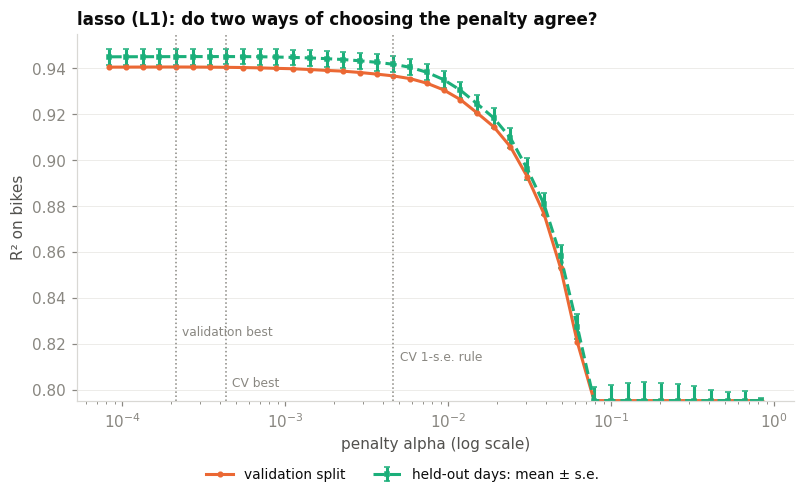

In [55]:
# The lasso penalty chosen by the held-out days against the one chosen by the validation split.
show(plots_p4.plot_cv_vs_validation(p4, "l1"))

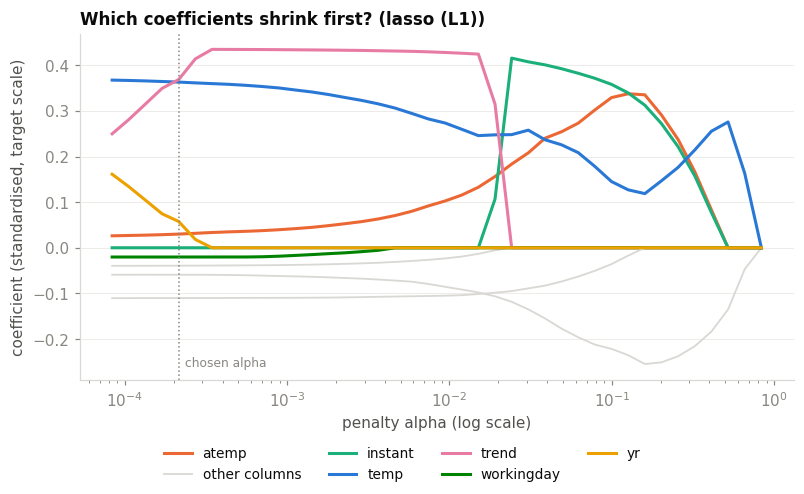

In [56]:
# How the lasso coefficients shrink as the penalty grows.
show(plots_p4.plot_paths(p4, "l1"))

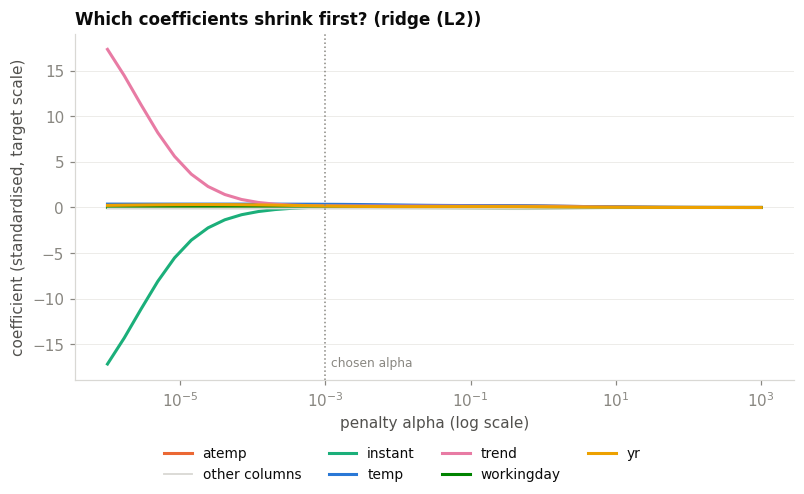

In [57]:
# The same for ridge, which shrinks but never sets a weight to zero.
show(plots_p4.plot_paths(p4, "l2"))

In [58]:
# Where each correlated pair enters the lasso path.
view.p4_entry(p4)

column,enters the lasso path at alpha
temp,6.595e-01
atemp,4.112e-01
yr,2.720e-04
instant,4.112e-01
trend,1.909e-02
workingday,3.654e-03
holiday,5.524e-04


### Justification: the verdict rule

We fixed the rule before running the phase. The reference model is Ridge at its chosen penalty on the full design; "dropping" a column means removing every feature built from it (for `hr` that includes all its interactions) and refitting.

- **Useful:** dropping the column alone lowers validation R² by at least 0.001, with a paired bootstrap interval that stays above zero.
- **Redundant:** dropping it alone costs nothing, but either dropping it together with its partner columns hurts, or the column on its own explains at least 0.01 of the variance. Its information is real but another column already carries it. Partners are the groups we measured to be copies of each other: {`temp`, `atemp`}, {`season`, `mnth`, `dteday`}, {`yr`, `instant`, `dteday`}, {`weekday`, `workingday`, `holiday`}.
- **Uninformative:** neither.
- **One representative per group.** If a group matters as a whole but no single member is missed when dropped, we keep the member that explains most on its own and call it useful; the others are redundant "carried by" it.

Lasso evidence is reported next to the drop tests (how many of the column's own features Lasso keeps, how often over 50 resamples of training days, and where it enters the path), but a Lasso zero alone does not decide a verdict: with copies in the design, which copy Lasso keeps is partly arbitrary.

In [59]:
# The verdict for every original column, from the drop tests.
view.p4_verdicts(p4)

column,verdict,"R² lost, column alone [interval]",with partners,alone explains,lasso keeps,best selection frequency,carried by,representative
atemp,redundant,"+0.0000 [-0.0001, +0.0002]",0.02289,0.1141,1/1,0.9200,temp,no
dteday,useful,"+0.0002 [-0.0004, +0.0008]",0.1203,0.1247,3/5,1.0000,,yes
holiday,redundant,"+0.0000 [-0.0000, +0.0000]",0.1851,1.909e-05,1/1,0.7800,"weekday, workingday",no
hr,useful,"+0.6594 [+0.6112, +0.7079]",–,0.4913,23/23,1.0000,,no
hum,useful,"+0.0055 [+0.0024, +0.0083]",–,0.1041,3/3,1.0000,,no
instant,redundant,"+0.0000 [-0.0000, +0.0000]",0.1029,0.08785,0/1,0.0000,dteday,no
mnth,redundant,"-0.0008 [-0.0015, -0.0001]",0.00386,0.06139,9/11,0.9400,dteday,no
season,redundant,"-0.0000 [-0.0001, -0.0000]",0.00386,0.05242,1/3,0.9800,dteday,no
temp,useful,"+0.0218 [+0.0164, +0.0283]",0.02289,0.09506,3/3,1.0000,,no
weathersit,useful,"+0.0100 [+0.0044, +0.0160]",–,0.01947,6/6,1.0000,,no


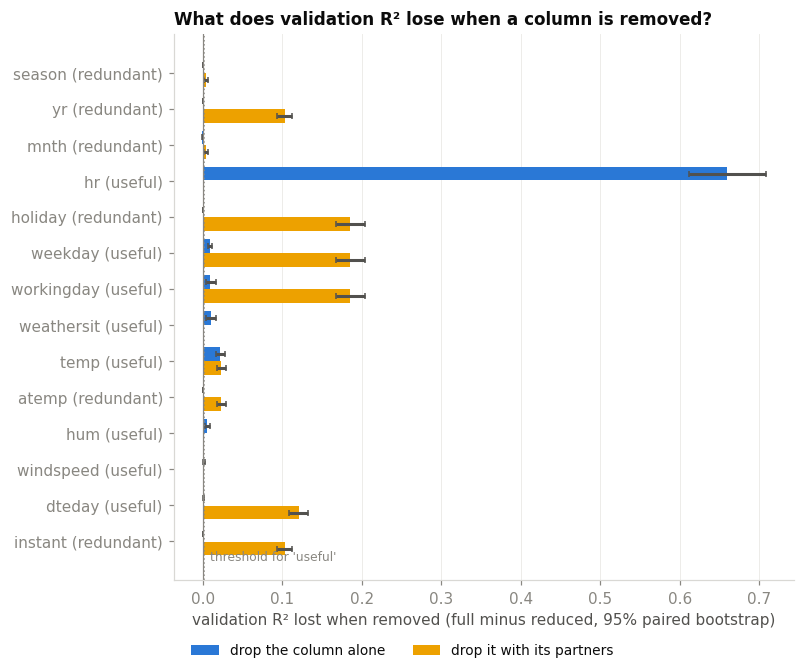

In [60]:
# The drop tests as a plot.
show(plots_p4.plot_verdicts(p4))

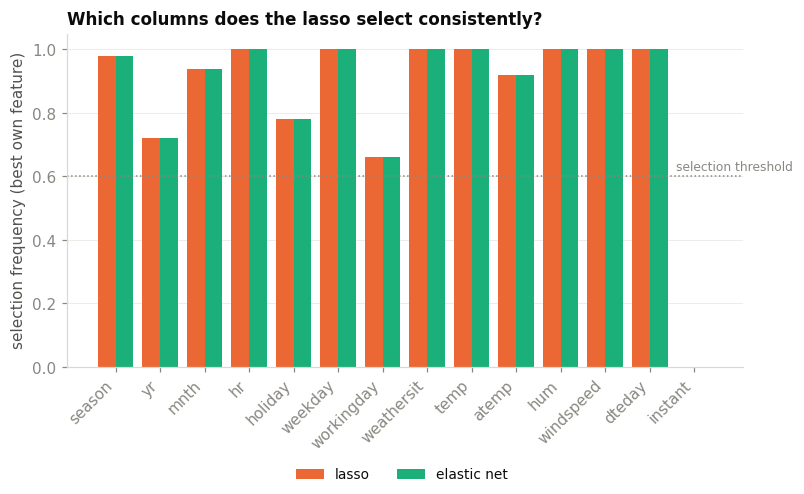

In [61]:
# How consistently the lasso selects each column when whole days are resampled.
show(plots_p4.plot_stability(p4))

### Justification: the survivor rule

The feature subset handed to Phase 5 is what L1 leaves non-zero, made reproducible. The order matters. We first remove every feature built from a column that is not "useful"; there are 280 features left. On that reduced design we run Lasso again (penalty chosen by validation R²: 8.4e-05), and a feature survives if its weight is non-zero (277 features) and it is selected in at least 0.6 of 50 Lasso fits on resampled training days (277 remain). To be plain about what this means: on this reduced design Lasso removes almost nothing, so the surviving subset is decided almost entirely by the column verdicts, and those verdicts were decided by drop tests scored on the validation set. The subset is a tuning decision made on validation rows, like the degree and the penalties; no feature statistic was fitted on them.

Our first version did it the other way round: take the Lasso zeros from the full design, then remove the copies. That turned out to be wrong for a reason worth stating. With month dummies, `yr` and `instant` in the design, Lasso let them stand in for some of the trend and day-of-year terms and zeroed those; the verdict step then removed the stand-ins as redundant, and the survivors had lost part of the time description twice. Validation R² hardly noticed, but the chronological score fell by about 0.013. Lasso should choose among features only after its choices are no longer between copies.

In [62]:
# The survivors: Lasso on the design of useful columns only, non-zero at its chosen penalty and stable over resampled days.
view.p4_survivors(p4)

item,value
"survivors, lasso_nonzero",277
"survivors, stable",277
"survivors, useful_design",280
selection lasso: penalty λ,8.351e-05
selection lasso: validation R²,0.9413
selection lasso: non-zero,277 of 280
selection lasso: fits that used all sweeps,0
original columns kept,"hr, weekday, workingday, weathersit, temp, hum, windspeed, dteday"
survivor columns (expanded features),277


### Justification: final model on the surviving columns

Stage A above answers "which columns matter" and needs every column in the design. It is not the model we want to ship: the columns judged redundant add nothing (dropping `mnth` alone changes validation R² by -0.0008, interval -0.0015 to -0.0001; a negative number means the model is better without it), and several of them are extra descriptions of time, which is exactly where our chronological split shows the model to be fragile. So we repeat the same search for the three methods on the surviving columns only (stage B) and recommend among those. The rule for choosing among the three methods was fixed before the first Phase 4 run: among the methods whose validation difference to the best is within the paired bootstrap noise, take the one with the best held-out-day R². What we added after seeing the first run is this second stage itself, that is, applying the rule to models fitted on the survivors; the earlier runs are in the git history.

In [63]:
# Stage B: the same search on the surviving columns only, and the method we recommend.
display(view.p4_methods(p4, "final"))
display(view.p4_unregularised(p4, "final"))
display(view.p4_comparisons(p4, "final"))
display(view.p4_recommended(p4))

method,penalty λ,l1 ratio,validation R²,interval low,interval high,held-out days R²,held-out days s.e.,chronological R²,non-zero weights,out of
elastic net,1.785e-04,0.9500,0.94127,0.93304,0.94896,0.94630,0.00345,0.93770,270,277
lasso (L1),1.696e-04,1.0000,0.94127,0.93305,0.94897,0.94630,0.00345,0.93771,270,277
ridge (L2),1.000e-06,0.0000,0.94125,0.93315,0.94886,0.94623,0.00345,0.93771,277,277


item,value
penalty λ,1.000e-08
chronological R²,0.93771
held-out days R²,0.94623
train R²,0.95060
train RMSE,40.08
validation R²,0.94125
validation RMSE,44.67


comparison,difference in validation R²,interval low,interval high
best - full_design_best,0.00064,-0.00029,0.00162
enet - l1,-0.00000,-0.00000,0.00000
enet - l2,0.00002,-0.00022,0.00025
enet - unregularised,0.00002,-0.00022,0.00025
l1 - l2,0.00002,-0.00022,0.00025
l1 - unregularised,0.00002,-0.00022,0.00025
l2 - unregularised,-0.00000,-0.00000,0.00000


item,value
stage B columns,277
stage B fits that used all sweeps,"{'count': 0, 'where': {}}"
methods within noise of the best,"ridge (L2), lasso (L1), elastic net"
recommended,lasso (L1)
fitted on,survivors
penalty λ,1.696e-04
l1 ratio,1.0000
validation R²,0.94127
held-out days R²,0.94630
chronological R²,0.93771


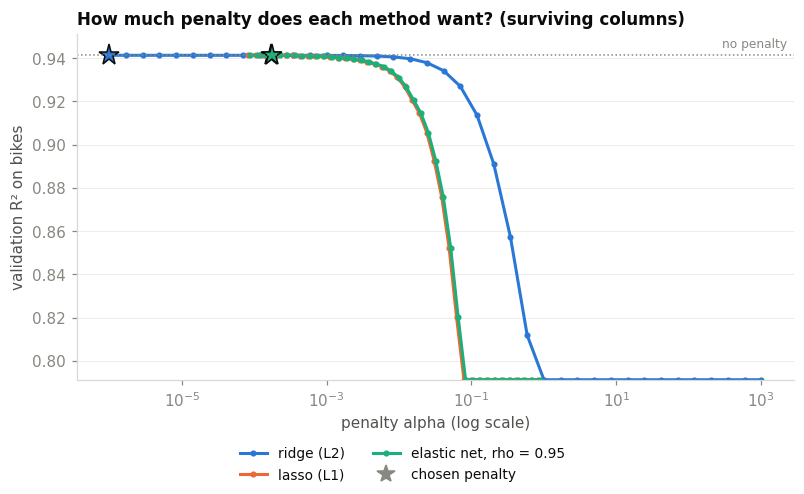

In [64]:
# The validation curves of stage B.
show(plots_p4.plot_validation_curves(p4, stage="final"))

In [65]:
# Does a penalty rescue the over-fit top of the ladder? (informational)
view.p4_rich(p4)

item,value
level,C10_month_x_wd_x_hr
weights (with bias),918
unregularised validation R²,0.9384
ridge (L2): held-out days R²,0.94346
ridge (L2): penalty λ,1.701e-03
ridge (L2): validation R²,0.93860
lasso (L1): held-out days R²,0.94477
lasso (L1): penalty λ,2.279e-03
lasso (L1): non-zero weights,587
lasso (L1): validation R²,0.93944


## Outcome — Phase 4

**What happened.**
- **The three methods are tied with each other, and the penalty buys very little.** On the full design: Ridge 0.9405, Lasso 0.9406, Elastic Net 0.9406 validation R², against 0.9393 without a penalty. Every paired interval between methods contains zero. The gain over no penalty is 0.0014 (interval 0.0004 to 0.0024): measurable on this design, which carries the duplicated columns, and small. The chosen penalties are tiny (Ridge 1.0e-03, Lasso 2.1e-04); Elastic Net chose l1_ratio 0.95, which makes it almost the same model as Lasso.
- **On the surviving columns the penalty buys nothing.** In stage B Ridge's best penalty is the smallest value on our grid (1e-06), which is our grid's way of saying "none": the unpenalised fit scores 0.9413 and the three methods 0.9413, 0.9413 and 0.9413. Once the copies are gone there is nothing left for regularization to fix, exactly what an "under-fit" diagnosis implies.
- **Where there is variance, the penalty works.** On the over-fit top ladder level Lasso raises validation R² from 0.9384 to 0.9394 while keeping 587 of 918 weights. That is still not better than our recommended model (difference -0.0018, interval -0.0046 to 0.0011).
- **Lasso is not sparse:** it keeps 285 weights. The signal is spread over many hour-specific columns.
- **Verdicts** (table above). Useful: `hr` (dropping it costs 0.659), `temp` (0.0218), `workingday` (0.0092), `weathersit` (0.0100), `weekday` (0.0088), `hum` (0.0055), `windspeed` (0.0014), and `dteday` as the kept representative of time. Redundant: `atemp` (dropping it costs 0.0000, dropping it together with `temp` costs 0.0229), `yr` and `instant` (together with the date terms 0.1029, alone nothing), `season` and `mnth`, and `holiday` (fully determined by `weekday` and `workingday`). No column came out uninformative.
- **Survivors:** 277 features from the eight useful original columns.
- **Final model (stage B):** recommended l1 with λ = 1.7e-04: validation R² 0.9413, RMSE 44.7 bikes, held-out days 0.9463, chronological 0.938. Our first pass, with the log target, ended at 0.9390, 45.5 bikes, 0.9428 and 0.914.

**What surprised us.**
- **Lasso's choices between copies were as arbitrary as we feared, and in one case backwards.** It keeps `atemp` in 0.92 of the resampled fits although dropping `atemp` costs nothing, and it never keeps `instant` (frequency 0.00) although `instant` alone explains 0.088 of the variance. "Lasso set it to zero" was evidence for us, but it would have misled us without the drop tests.
- **`dteday` is useful only as a group.** Dropping the trend and day-of-year terms alone costs 0.0002, because `yr`, `instant`, `season` and `mnth` then step in; dropping them all costs 0.120. We had predicted the copies would be redundant; we had not expected them to be able to replace the original so completely.
- **`mnth` is slightly harmful.** Removing it improves validation R² (see above). Month dummies add steps to a season that the smooth day-of-year terms already describe.
- **`windspeed` is useful, but only as we represent it now.** In our very first Phase 4 run, with wind as a single linear column, the same rule called it uninformative; with the square and the interaction with temperature that Phase 3 added, dropping it costs 0.0014 with an interval that just clears zero. We predicted it might flip back in the second pass; it did not. A verdict about a column is a verdict about the column *as we represented it*.
- **Our own survivor rule was wrong at first** (see the justification above): taking Lasso zeros before removing the copies quietly cost robustness on later months.
- **Second pass:** every verdict is the same as with the log target, and the three methods are tied again, as we expected. The recommended method changed from Elastic Net to l1; with the methods tied within noise that is the tie-break on held-out days, not a finding.
- Some Lasso fits at one large penalty value on the full design ran out of sweeps (7 fits; none is a chosen model). The exactly duplicated columns are the cause; on the survivors every fit converged.

**Handed to Phase 5:** the surviving feature list. Handed to the submission: the stage-B recommended model.

## Expectation — Phase 5: Logistic Regression

*Written before running the phase (see the git history of this file).*

**What we do.** We turn `cnt` into a yes/no target, "is this a high-demand hour?", and train our own logistic regression (gradient descent on the log-loss) using only the feature columns that survived Phase 4, loaded from `artifacts/p4.json`.

**The flaw of a single global threshold, as we see it.** If "high" means "more than the 75th percentile of all hours", then high demand is simply 8 am and 5–6 pm on working days and midday at weekends. A classifier for that label only has to read the clock; it tells the operator nothing they do not already know from the timetable. A threshold per (working day, hour) fixes the clock problem but creates a calendar one: demand grew about 65% from 2011 to 2012, so nearly every "high" hour would be a 2012 hour.

**Our label.** An hour is high-demand when its `cnt` is above the 75th percentile of training hours with the same year, day type and hour of day. The 96 thresholds are computed on the training portion only and looked up for validation rows. "High" then means "busier than three quarters of comparable hours", which is the case where the usual allocation of bikes is not enough.

**What we expect, and why.**

1. *Class balance.* About 25% positives in training and validation, and about the same in each year. The majority-class accuracy is therefore about 0.75, so accuracy alone will flatter any model; we will read F1, precision, recall, ROC-AUC and PR-AUC together.
2. *The foils.* Under the global threshold, hour dummies alone should reach an AUC near 0.85 and the full model near 0.98: impressive and useless. Under the (working day, hour) rule without year, the trend alone should reach about 0.8. Under our rule, hour alone should sit at chance (0.50) and trend alone close to it.
3. *Our classifier.* With the easy cues removed, the model has to rely on weather and season. We expect ROC-AUC between 0.82 and 0.88, well below the foil's number, and we will treat that lower figure as the honest one. Accuracy at a 0.5 cut-off should be only a few points above 0.75.
4. *Operating threshold.* Missing a high-demand hour (empty docks) is worse than a false alarm (a few idle bikes). With the same 3:1 cost ratio as the Phase 1 bonus, the cost-minimising cut-off for a calibrated model is 1/(1+3) = 0.25, not 0.5. We expect recall to rise sharply and precision to fall at 0.25, and the validation cost curve to have its minimum near 0.25 if our probabilities are well calibrated.
5. *Features.* Hour dummies should matter little on their own here, because the label is already relative to the hour; temperature, humidity, weather situation and the day-of-year terms should carry the model.

## Expectation — Phase 5, second pass

*Written before re-running the chain with the power target (λ = 0.1). The cell above is unchanged.*

The label and the classifier do not use the regression target, so Phase 5 changes only if the surviving feature list
changes. We expect the same class balance and a ROC-AUC within 0.005 of the first pass (0.886). A tree model that we
tried outside the pipeline reaches about 0.90 on the same label, so we do not expect the logistic model to go higher
than that.

### Justification: label rule

- **The flaw of one global threshold.** If "high" means "above the 75th percentile of all hours", the label is the timetable: 8h and 17–18h on working days, midday at weekends. In the table below, hour dummies alone then reach a ROC-AUC of 0.855 and the full model 0.985. That looks excellent and tells the operator nothing new.
- **Fixing the clock creates a calendar problem.** With one threshold per (day type, hour), hour alone drops to 0.533, but because demand grew so much, only 0.054 of 2011 validation hours are "high" against 0.421 of 2012 hours, and the trend alone reaches 0.810. Now the label is the year.
- **Our rule.** An hour is high-demand when `cnt` is above the 0.75 quantile of training hours with the same year, day type and hour: 96 thresholds, each from at least 50 training hours, looked up for validation rows. Hour alone is at chance (0.501), trend alone nearly so (0.577), and the positive share is the same in both years (0.239 and 0.262).
- **Why this is meaningful for the operator.** The operator already plans for rush hours and for growth. What they cannot read off a timetable is whether *this* 8 am will be busier than a normal 8 am this year. The top quarter of comparable hours is where a normal allocation of bikes runs short.
- **Why the 75th percentile.** It keeps enough positives to learn from (about a quarter) while still meaning "clearly above normal"; a 90th percentile would leave about five positives in the smallest cells.
- **Limit.** A new year has no cell of its own; in use, the thresholds would have to be rolled forward, for example last year's cell scaled by the fitted trend.

In [66]:
# Phase 5 builds the high-demand label from training-row thresholds and fits our own logistic regression on the Phase 4 survivors; a full run takes about three minutes, so the stored artifact is loaded when nothing upstream changed.
from src import plots_p5
from src.logistic import fit_logistic, logloss, logloss_grad, sigmoid
from src.phases import p5 as p5mod

p5 = phase("p5", p5mod.run, CFG, upstream="p4", recompute_all=RECOMPUTE_ALL)   # writes artifacts/p5.json when it has to run

loaded cached artifacts/p5.json (same config and upstream artifact); run `python run.py p5` or change CFG to recompute


In [67]:
# The chain: every feature of this phase must be a survivor of Phase 4.
rows = view.p5_chain_rows(p4, p5)
assert all(passed for *_, passed in rows), "Phase 5 uses a column that Phase 4 dropped"
display(view.checks(rows, "Phase 5 consumed Phase 4"))
view.p5_design(p5)

check,value,result
every Phase 5 feature is a Phase 4 survivor,"277 features, 277 survivors from ['hr', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'dteday']",passed


item,value
features (no bias),277
columns including bias,278
training rows,8708
validation rows,2178


In [68]:
# The label: high demand means above a quantile of training hours with the same year, day type and hour.
display(view.p5_thresholds(p5))
view.p5_balance(p5)

year,day type,hour 3,hour 8,hour 12,hour 17
2011,non-working day,30.0,101.0,375.5,364.5
2011,working day,6.0,438.0,195.0,552.0
2012,non-working day,40.0,170.0,543.0,555.0
2012,working day,6.0,692.0,305.5,812.0


item,value
"positives, train",0.2455
"positives, validation",0.2502
"positives, validation 2011",0.2386
"positives, validation 2012",0.2615
majority-class accuracy,0.7498


In [69]:
# The foils: the same three models under three label rules. Only the last rule keeps the hour and the trend at chance.
view.p5_label_variants(p5)

label rule,"positives, train","positives, validation",validation 2011,validation 2012,"AUC, hour only","AUC, trend only","AUC, all columns",accuracy at 0.5,majority accuracy
global,0.250,0.239,0.154,0.321,0.855,0.662,0.985,0.949,0.761
workingday + hr,0.245,0.240,0.054,0.421,0.533,0.810,0.937,0.894,0.760
yr + workingday + hr,0.246,0.250,0.239,0.262,0.501,0.577,0.885,0.827,0.750


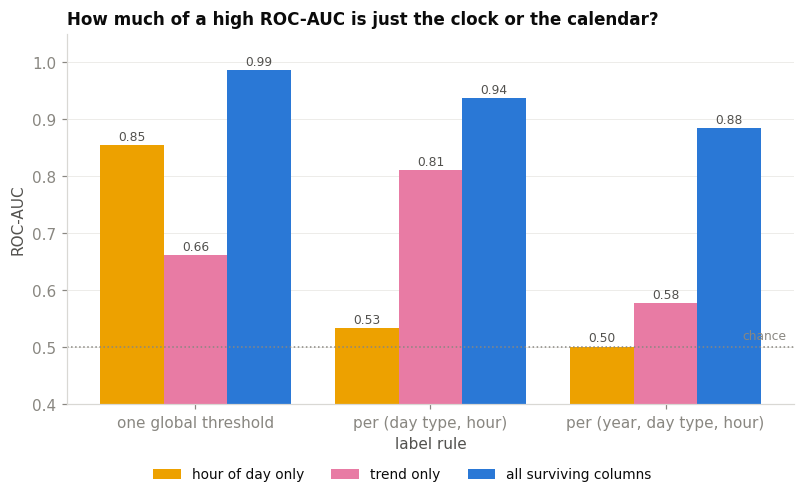

In [70]:
# The foils as a plot.
show(plots_p5.plot_label_variants(p5))

### Justification: regularisation of the classifier

The classifier is our own logistic regression: gradient descent on the mean log-loss, with the step 1/(λ_max/4 + l2), which is the safe step for this loss because its curvature is at most a quarter of that of the squared loss. It uses only the Phase 4 survivors (the assert above). We add a small ridge term because, without any penalty, some weights of rarely active columns keep growing and gradient descent does not settle (the l2 = 0 row below stops at the iteration cap). The strength is chosen by validation ROC-AUC among 0.0, 0.0001, 0.001 and 0.01; ties within 0.0001 go to the larger value. Chosen: 0.001.

In [71]:
# The ridge strength of the classifier, chosen by validation ROC-AUC, and how the chosen fit ended.
display(view.p5_l2_sweep(p5))
display(view.p5_fit(p5))

ridge strength,iterations,stop reason,train log-loss,validation log-loss,validation ROC-AUC
0.000e+00,50000,max_iter,0.30794,0.36894,0.88329
1.000e-04,11105,converged,0.30802,0.36326,0.88452
1.000e-03,2954,converged,0.30965,0.35833,0.88495
1.000e-02,574,converged,0.32726,0.36325,0.88013


item,value
chosen ridge strength,1.000e-03
iterations,2954
stop reason,converged
learning rate,1.1590
gradient check at zeros (max relative error),4.9e-08
gradient check halfway to the final weights,7.1e-08


In [72]:
# Our logistic regression: the log-loss, its gradient, and the fit, which reuses the Phase 1 gradient-descent loop.
show_source(sigmoid, logloss, logloss_grad, fit_logistic)

def sigmoid(eta):
    """Numerically stable 1/(1+exp(-eta)): never exponentiates a positive number."""
    eta = np.asarray(eta, dtype=np.float64)
    e = np.exp(-np.abs(eta))
    return np.where(eta >= 0, 1.0 / (1.0 + e), e / (1.0 + e))

def logloss(X, y, w, l2=0.0):
    """Mean cross-entropy via -log p = logaddexp(0, -eta), -log(1-p) = logaddexp(0, eta)."""
    eta = X @ w
    data_term = np.mean(y * np.logaddexp(0.0, -eta) + (1.0 - y) * np.logaddexp(0.0, eta))
    return float(data_term + 0.5 * l2 * np.sum(w[1:] ** 2))

def logloss_grad(X, y, w, l2=0.0):
    """(1/n) X'(p - y) + l2 * w with the bias entry of the penalty set to 0."""
    grad = X.T @ (sigmoid(X @ w) - y) / X.shape[0]
    grad[1:] += l2 * w[1:]
    return grad

def fit_logistic(X, y, l2=0.0, lr=None, tol_loss=1e-10, tol_grad=1e-6, max_iter=50000):
    """Gradient descent from w = 0.  Default lr = 1/(lambda_max(X'X/n)/4 + l2).

    The Hessian is at most (1/4) X'X/n + l2 I, so this step is 1/L for the smoothness L.
   

### Justification: metrics

About one hour in four is positive, so a model that always answers "normal" has an accuracy of 0.750. Accuracy alone would flatter us, so we read it together with: **recall** (how many high-demand hours we catch, the operator's main concern), **precision** (how many alarms are real), **F1** (their balance), **ROC-AUC** (ranking quality, independent of the cut-off and of the class balance) and **PR-AUC** (ranking quality on the positive class, more demanding when positives are the minority). The task's three required numbers, accuracy, F1 and ROC-AUC, are reported at our operating cut-off; the others are shown beside them.

In [73]:
# Validation metrics at the cost-based cut-off, at 0.5 and at the F1-optimal cut-off, and the confusion matrix.
display(view.p5_metrics(p5))
display(view.p5_confusion(p5))

cut-off,threshold,accuracy,F1,precision,recall,ROC-AUC,PR-AUC,cost
at 1/(1+c),0.2500,0.7842,0.6589,0.5450,0.8330,0.8850,0.7280,0.2994
at 0.5,0.5000,0.8269,0.6278,0.6795,0.5835,0.8850,0.7280,0.3815
at F1-optimal,0.3500,0.8140,0.6694,0.6029,0.7523,0.8850,0.7280,0.3099
"training rows, at 1/(1+c)",–,0.8089,0.6907,–,–,0.9146,–,–


truth,predicted normal,predicted high
truly normal,1254,379
truly high,91,454


### Justification: operating threshold

A missed high-demand hour means empty docks and lost customers; a false alarm means a few idle bikes. We use the same 3:1 cost ratio as in the Phase 1 bonus. For a model whose probabilities are calibrated, raising an alarm is worth it when p × 3 > (1 − p) × 1, that is when p > 1/(1+3) = 0.25. So our cut-off is 0.25, not the habitual 0.5. The plot below checks the argument on the validation rows: the cost is lowest at 0.2 on our grid, and the calibration plot further down shows how far the probabilities can be trusted (largest gap 0.091).

item,value
cost ratio (miss : false alarm),3.0000
cost-based cut-off 1/(1+c),0.2500
grid threshold with the lowest validation cost,0.2000
grid threshold with the highest F1,0.3500


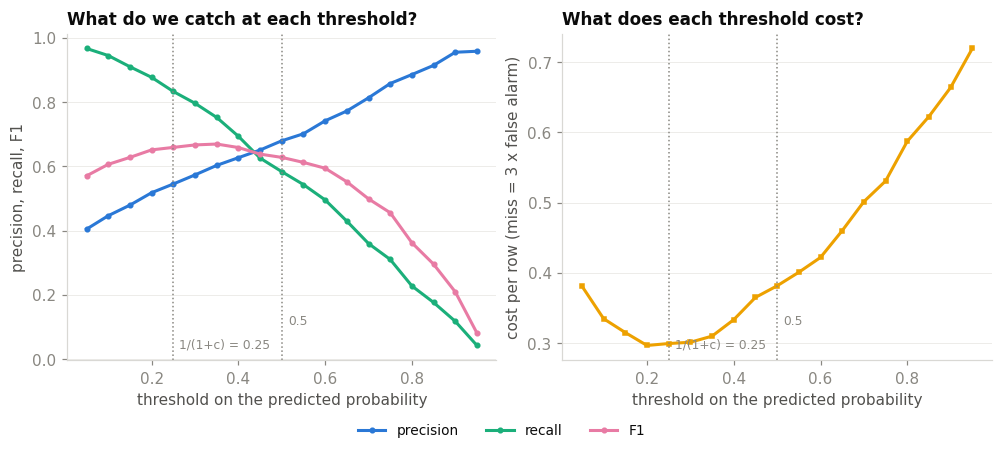

In [74]:
# Where the alarm threshold should sit when a miss costs more than a false alarm.
display(view.p5_threshold(p5))
show(plots_p5.plot_threshold_curve(p5))

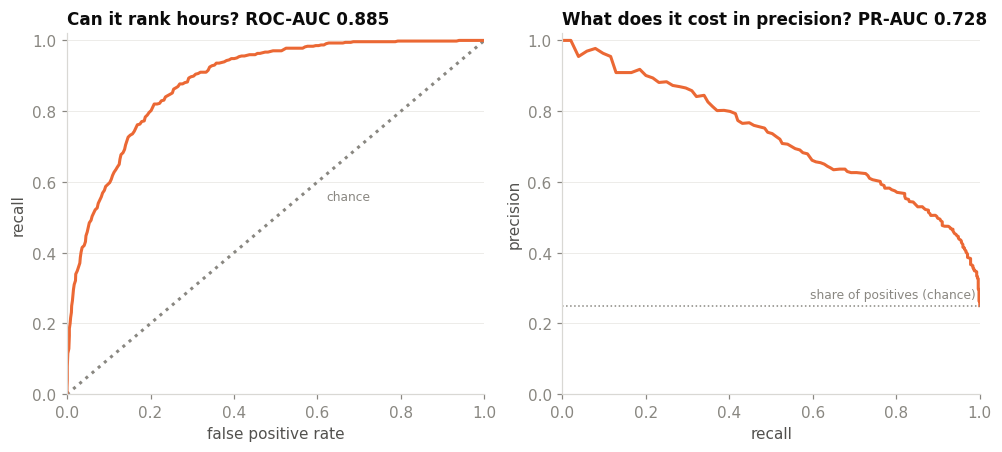

In [75]:
# How well the classifier ranks hours.
show(plots_p5.plot_roc_pr(p5))

item,value
largest gap between predicted and observed share (bins with >= 30 rows),0.09067


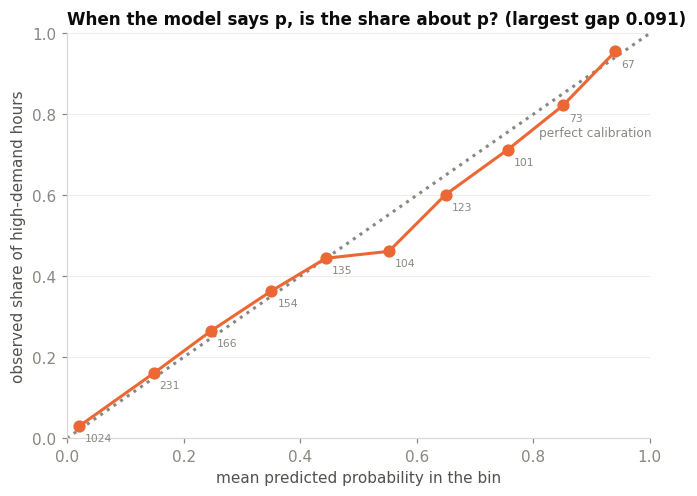

In [76]:
# Whether the predicted probabilities can be trusted.
display(view.p5_calibration(p5))
show(plots_p5.plot_calibration(p5))

In [77]:
# What the classifier relies on: the largest standardised weights, and the share of each original column.
display(view.p5_top_coefficients(p5))
view.p5_column_share(p5)

feature,standardised weight
temp,2.152
temp^2,-1.004
doy_s1,-0.872
temp^3,-0.832
doy_c1,-0.791
hum,-0.418
doy_s2,-0.392
wk_5,0.376
wk_2*hr_6,0.373
hr_3*temp,-0.361


original column,share of sum |w|
dteday,0.052
hr,0.412
hum,0.042
temp,0.161
weathersit,0.028
weekday,0.262
windspeed,0.005
workingday,0.038


### Pipeline retrospective

Each phase used what the previous one produced, and the table below is built from the five artifact files.

- **Phase 1** gave a working optimiser and an honest baseline: validation R² 0.736 with 36 weights. Its residuals showed the missing structure.
- **Phase 2** started from Phase 1's weights (first loss equal to Phase 1's last) and added what those residuals asked for: R² 0.918.
- **Phase 3** showed that this model was still too simple, not too flexible, and that the gap to a chronological split is drift rather than leakage. It moved the target to 282 weights: 0.941 on validation, 0.946 on held-out days, 0.938 chronologically.
- **Phase 4** found, as that diagnosis implies, that penalties change little (all three methods within noise of each other), used them to sort the 14 columns into useful, redundant and uninformative, and recommended l1 on the 277 surviving features: R² 0.941, RMSE 44.7.
- **Phase 5** reused exactly those features for a classifier: ROC-AUC 0.885, F1 0.659, accuracy 0.784 at the cost-based cut-off.

The thread through all five: on this data the errors come from bias. Every gain came from giving the linear model structure the data really has; the classical variance cures (higher degree, stronger penalty) did nothing measurable. **The regression model our pipeline recommends, and the one behind our submission, is the Phase 4 stage-B model.**

In [78]:
# The five phases side by side, built from the five artifact files.
view.p5_retrospective(p5)

phase,consumed,settings,result,weights,train score,validation score,validation RMSE
P1 gradient descent,"35 base columns + bias, power-family target (exponent 0.1)","lr=0.506, 496 iterations",,36,0.7462,0.7361,94.6902
P2 polynomial,P1 weights as the starting point,"degree=3 on temp, blocks=wd_x_hr",gain over P1 = 0.1817 R2,61,0.9206,0.9178,52.8411
P3 bias-variance,P2 design as anchor of a 11-level ladder,target C6_weather_detail (282 weights),target seeded/day-block/chrono = 0.941/0.946/0.938; anchor = 0.918/0.918/0.894,282,0.9506,0.9413,44.6534
P4 regularization,P3 target design + the held-back candidate columns,l2 lambda=0.001 val_r2=0.9405; l1 lambda=0.000215 val_r2=0.9406; enet lambda=0.000226 val_r2=0.9406; recommended l1 lambda=0.00017,277 surviving columns from 8 original columns,278,–,0.9413,44.6655
P5 logistic,"P4 surviving columns, label = above the 75th percentile of yr+workingday+hr","l2=0.001, threshold 0.25, 2954 iterations","accuracy 0.784, F1 0.659, ROC-AUC 0.885",278,0.9146,0.8850,–


## Outcome — Phase 5

**What happened.**
- Class balance is as planned: 0.246 positives in training, 0.250 in validation, 0.239 and 0.262 by year.
- The foils behaved as predicted: global threshold, hour-only AUC 0.855 and full model 0.985; our rule, hour-only 0.501.
- Our classifier: ROC-AUC 0.885 (95% interval 0.869–0.900), PR-AUC 0.728. At the cut-off 0.25: accuracy 0.784, F1 0.659, precision 0.545, recall 0.833. At 0.5: accuracy 0.827, F1 0.628, recall 0.583.
- The cost argument holds up: at 0.25 we miss 91 high-demand hours and raise 379 false alarms (cost 0.299 per hour); at 0.5 we would miss 227 (cost 0.382).

**What surprised us.**
- Accuracy is *lower* at our chosen cut-off (0.784) than at 0.5 (0.827), and barely above the do-nothing baseline of 0.750. Judged by accuracy alone our operating point looks like a mistake; judged by the operator's cost it is clearly the better one. This is the clearest case in the project of a metric pointing the wrong way.
- The cost argument holds up in practice: on our grid of cut-offs (steps of 0.05) the validation cost is lowest at 0.2, next to the theoretical 0.25, and the probabilities are usable but not perfectly calibrated (largest gap 0.091). We kept the theoretical cut-off instead of tuning it on the validation rows.
- *Second pass:* as expected the classifier hardly moved (ROC-AUC 0.885 against 0.886), because neither the label nor the features depend on the regression target; only the survivor list changed slightly. The chosen ridge strength changed to 0.001, by a margin inside the noise of the validation AUC.
- The honest task is much harder than the trivial one (AUC 0.885 against 0.985). Whether an hour is unusually busy for its slot depends on things we only partly observe: the weather explains some of it, events and school holidays are not in the data.
- Even with the label made relative to the hour, hour-related columns still carry a large share of the weights (table above): the weather effect differs by hour, so the survivors' hour × weather interactions matter even though the hour alone predicts nothing.

## Phase 6 — Final model and submission

**Which model.** The regression model our pipeline recommends is the Phase 4 stage-B model: l1 with λ = 1.7e-04 and l1_ratio 1.0 on the surviving features. Nothing is tuned here.

**Refit on training + validation, and why.** The hyper-parameters stay exactly as validated, but the weights are refitted on all 10886 labelled rows. The Phase 3 learning curve of the target was still rising at full size (0.940 with 80% of the training days, 0.941 with all of them), so a quarter more rows should help a little, and the validation rows are days of the same months as the hidden ones. The scaler and the humidity fill stay as fitted on the training portion, so the hidden rows go through exactly the transformations used everywhere else. The cell first refits the validated model on the training rows alone and asserts that it reproduces the Phase 4 weights.

**What we check without labels.** We cannot score the hidden days, and we do not tune anything on them. We only check that the predictions are sane: same rows and order as `test.csv`, no missing or negative values, the refitted model agrees closely with the validated one (correlation 0.9997), and the predicted hourly profile by day type looks like the training profile (each cell between 0.81 and 1.15 times the training mean).

**What the model cannot adapt to.** It extrapolates growth as a straight line on the transformed scale, which Phase 3 showed to be somewhat too steep beyond the observed period; it has never seen a zero-demand hour, weather outside the observed range, or holidays other than those in the training days. For the hidden days, which lie inside the two observed years, the held-out-day estimate of Phase 4 (0.946) is our best guess of the score; for a genuinely later period we would expect something nearer the chronological estimate (0.938).

In [79]:
# Phase 6 refits the recommended Phase 4 model on training plus validation rows and predicts the hidden days; it re-runs no earlier phase.
from src import predict
from src.common import load_test, read_artifact

p6 = predict.run(CFG)   # writes sample_submission.csv and artifacts/p6.json

In [80]:
# What was submitted and how it compares with the model that was validated (model A, training rows only).
view.p6_summary(p6)

item,value
model (Phase 4 recommended),lasso (L1)
penalty λ,1.696e-04
l1 ratio,1.0000
refit on,train+validation
rows used to fit,10886
rows predicted,574
model A reproduces the Phase 4 weights (max gap),0.0000
prediction mean,199.3179
prediction median,161.1400
prediction min,0.9400


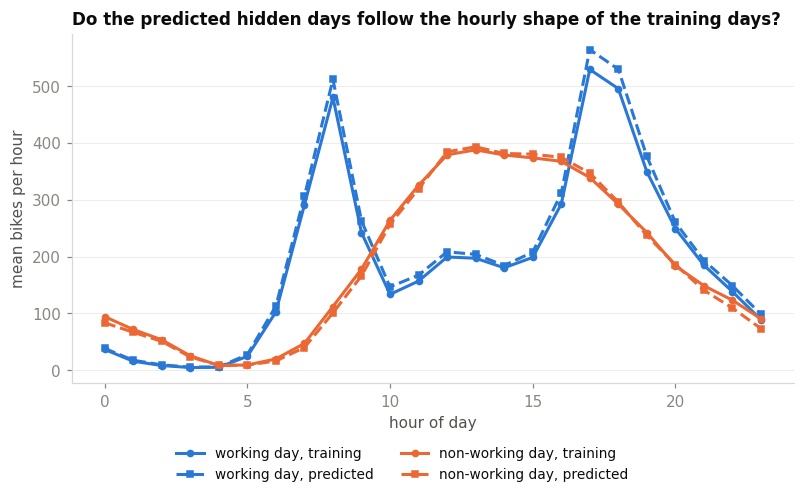

In [81]:
# The predicted hourly profile of the hidden days against the profile of the training days.
test_df = load_test(CFG)
sub = pd.read_csv(predict.SUBMISSION_PATH)
show(plots_p5.plot_test_profile(train_all, test_df, sub))

In [82]:
# The same checks as tools/submission_check.py, inline: any failure stops the notebook.
assert list(sub.columns) == ["instant", "cnt"], list(sub.columns)
assert len(sub) == len(test_df), (len(sub), len(test_df))
assert (sub["instant"].to_numpy() == test_df["instant"].to_numpy()).all(), "row order differs from the hidden file"
assert np.isfinite(sub["cnt"].to_numpy(dtype=float)).all(), "NaN or inf in cnt"
assert (sub["cnt"] >= 0).all(), "negative predictions"
assert not (sub["cnt"] == 0).all(), "all predictions are 0"
view.p6_submission(sub, p6)

item,value
submission shape,"574, 2"
columns,"instant, cnt"
asserted above,"columns, row count and order equal the hidden file; no NaN; no negatives; not all zero"
cells outside the 0.4-2.5 band of the training profile,0
daily totals against same-month training days,0.85 to 1.58


In [83]:
# All chain assertions in one table: hash chain p1 to p6, one shared seed, the hand-overs between phases.
arts = {name: read_artifact(name) for name in ("p1", "p2", "p3", "p4", "p5", "p6")}
rows = view.p6_chain_rows(arts, CFG)
assert all(passed for *_, passed in rows), "a chain assertion failed"
view.checks(rows, "Chain assertions")

check,value,result
p2.upstream_sha256 == sha256(artifacts/p1.json),hash equal,passed
p3.upstream_sha256 == sha256(artifacts/p2.json),hash equal,passed
p4.upstream_sha256 == sha256(artifacts/p3.json),hash equal,passed
p5.upstream_sha256 == sha256(artifacts/p4.json),hash equal,passed
p6.upstream_sha256 == sha256(artifacts/p5.json),hash equal,passed
p1 has no upstream,none,passed
same seed in p1..p6 and equal to the seed of the config,44615,passed
p2 starts from the p1 weights,p1,passed
p2.init_loss == p1.train_loss_final (1e-9),difference 0.0e+00,passed
p5.features are a subset of p4.survivors_expanded,277 of 277,passed


### The pipeline at a glance

One line per phase, built from the five artifact files: what each phase consumed, what it handed on, and the score of the model it ended with. This is the same table as the retrospective in Phase 5, placed here so that the notebook ends with the whole chain in view.

phase,consumed,settings,weights,validation score,held-out days R²,chronological R²
P1 gradient descent,"35 base columns + bias, power-family target (exponent 0.1)","lr=0.506, 496 iterations",36,0.7361,–,–
P2 polynomial,P1 weights as the starting point,"degree=3 on temp, blocks=wd_x_hr",61,0.9178,0.9180,0.8941
P3 bias-variance,P2 design as anchor of a 11-level ladder,target C6_weather_detail (282 weights),282,0.9413,0.9462,0.9378
P4 regularization,P3 target design + the held-back candidate columns,l2 lambda=0.001 val_r2=0.9405; l1 lambda=0.000215 val_r2=0.9406; enet lambda=0.000226 val_r2=0.9406; recommended l1 lambda=0.00017,278,0.9413,0.9463,0.9377
P5 logistic,"P4 surviving columns, label = above the 75th percentile of yr+workingday+hr","l2=0.001, threshold 0.25, 2954 iterations",278,0.8850,–,–


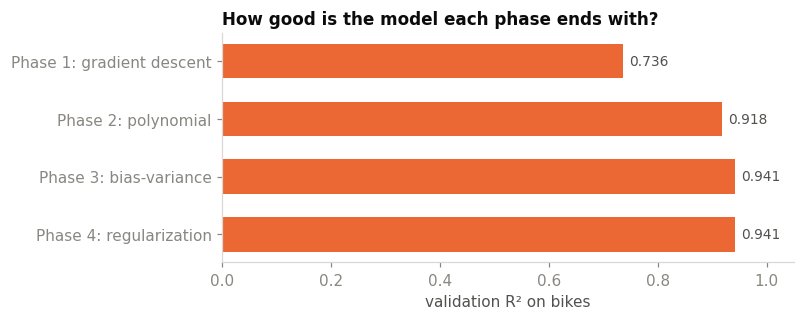

In [84]:
# The whole chain in one table and one figure.
display(view.pipeline_summary(p1, p2, p3, p4, p5))
show(plots.plot_pipeline_summary(p1, p2, p3, p4))